## make a table first

In [ ]:
import pandas as pd
import os

# Check if the CSV file exists first
csv_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/Maths_subjective_grading - Sheet6.csv"

print("=== CSV FILE CHECK ===")
print(f"CSV path: {csv_path}")
print(f"File exists: {os.path.exists(csv_path)}")

if os.path.exists(csv_path):
    print(f"File size: {os.path.getsize(csv_path)} bytes")
    
    try:
        # Safe CSV loading
        print("\n🔄 Loading CSV...")
        df = pd.read_csv(csv_path, low_memory=False)
        print(f"✅ Successfully loaded CSV")
        print(f"Shape: {df.shape}")
        print(f"Columns: {list(df.columns)}")
        print("\nFirst few rows:")
        print(df.head())
        
    except Exception as e:
        print(f"❌ Error loading CSV: {e}")
        df = None
else:
    print("❌ CSV file not found!")
    df = None


In [ ]:
# SAFE JSON PARSING HELPER FUNCTION
import json

def safe_json_parse(raw_text, context_name="unknown"):
    """
    Safely parse JSON with detailed error reporting
    """
    print(f"\n=== PARSING JSON FROM {context_name.upper()} ===")
    
    # Debug the raw input
    print(f"Type: {type(raw_text)}")
    print(f"Length: {len(raw_text) if raw_text else 0}")
    print(f"Is None: {raw_text is None}")
    print(f"Is empty: {raw_text == '' if raw_text is not None else 'N/A'}")
    
    if raw_text:
        print(f"First 100 chars: {repr(raw_text[:100])}")
        if len(raw_text) > 200:
            print(f"Last 100 chars: {repr(raw_text[-100:])}")
    
    # Attempt parsing
    try:
        if raw_text and raw_text.strip():
            print("\n🔄 Attempting to parse JSON...")
            result = json.loads(raw_text)
            print("✅ Successfully parsed JSON")
            print(f"Result type: {type(result)}")
            return result
        else:
            print("❌ Input is empty, None, or whitespace only")
            return None
            
    except json.JSONDecodeError as e:
        print(f"\n❌ JSON parsing error: {e}")
        print(f"Error at line {e.lineno}, column {e.colno}, position {e.pos}")
        if raw_text and len(raw_text) > e.pos:
            start = max(0, e.pos-30)
            end = min(len(raw_text), e.pos+30)
            print(f"Content around error:")
            print(f"'{raw_text[start:end]}'")
            print(f"{' ' * (e.pos - start)}^")
        return None
    except Exception as e:
        print(f"❌ Unexpected error: {type(e).__name__}: {e}")
        return None

# Example usage (replace 'your_raw_text_variable' with actual variable):
# json_result = safe_json_parse(your_raw_text_variable, "API response")


In [2]:
import os
import json

class OCRComparator:
    def __init__(self, human_dir, gemini_dir, output_dir):
        """
        Initialize with just 3 base directories
        """
        self.human_dir = human_dir
        self.gemini_dir = gemini_dir  
        self.output_dir = output_dir
        
        print(f"📁 Human OCR directory:  {self.human_dir}")
        print(f"🤖 Gemini OCR directory: {self.gemini_dir}")
        print(f"💾 Output directory:     {self.output_dir}")
        print("=" * 70)
    
    def compare_solution_files(self, solution_folder, solution_number, file_prefix):
        """
        Compare a single solution file between human and Gemini OCR
        """
        # Build file paths using the base directories
        human_file = os.path.join(
            self.human_dir, solution_folder, f"{file_prefix}_solution_{solution_number}.json"
        )
        
        gemini_file = os.path.join(
            self.gemini_dir, solution_folder, f"{file_prefix}_solution_{solution_number}.json"
        )
        
        output_file = os.path.join(
            self.output_dir, solution_folder, f"{file_prefix}_solution_{solution_number}_table.json"
        )
        
        print(f"🔄 Processing solution {solution_number} in {solution_folder}")
        
        # Initialize combined data structure
        combined_data = {
            "question_number": solution_number,
            "human_text": "NA",
            "ocr_text": "NA",
            "ocr_pages": [],
            "pdf_name": solution_folder  # Add pdf source info
        }
        
        # Read Human OCR data
        if os.path.exists(human_file):
            try:
                with open(human_file, 'r', encoding='utf-8') as f:
                    human_data = json.load(f)
                    
                if isinstance(human_data, list) and len(human_data) > 0:
                    human_item = human_data[0]
                    combined_data["human_text"] = human_item.get('solution_text', 'NA')
                    combined_data["question_number"] = human_item.get('question_number', solution_number)
                    print(f"   ✅ Human text loaded: {len(str(combined_data['human_text']))} chars")
                else:
                    print(f"   ⚠️  Human file format issue: {human_file}")
                    
            except Exception as e:
                print(f"   ❌ Error reading human file: {e}")
        else:
            print(f"   ❌ Human file not found: {human_file}")
        
        # Read Gemini OCR data
        if os.path.exists(gemini_file):
            try:
                with open(gemini_file, 'r', encoding='utf-8') as f:
                    gemini_data = json.load(f)
                    
                if isinstance(gemini_data, list) and len(gemini_data) > 0:
                    gemini_item = gemini_data[0]
                    combined_data["ocr_text"] = gemini_item.get('solution_text', 'NA')
                    combined_data["ocr_pages"] = gemini_item.get('pages', [])
                    print(f"   ✅ Gemini text loaded: {len(str(combined_data['ocr_text']))} chars")
                    print(f"   📄 Pages: {combined_data['ocr_pages']}")
                else:
                    print(f"   ⚠️  Gemini file format issue: {gemini_file}")
                    
            except Exception as e:
                print(f"   ❌ Error reading Gemini file: {e}")
        else:
            print(f"   ❌ Gemini file not found: {gemini_file}")
        
        # Save combined data
        os.makedirs(os.path.dirname(output_file), exist_ok=True)
        
        try:
            with open(output_file, 'w', encoding='utf-8') as f:
                json.dump(combined_data, f, indent=2, ensure_ascii=False)
            print(f"   💾 Saved: {os.path.basename(output_file)}")
            return True
        except Exception as e:
            print(f"   ❌ Error saving output: {e}")
            return False
    
    def process_all_solutions(self):
        """
        Process all solution folders and files
        """
        if not os.path.exists(self.human_dir):
            print(f"❌ Human directory not found: {self.human_dir}")
            return
            
        total_processed = 0
        successful = 0
        errors = 0
        
        print(f"🔍 Scanning human directory: {self.human_dir}")
        
        # Iterate through all solution folders
        for solution_folder in os.listdir(self.human_dir):
            solution_folder_path = os.path.join(self.human_dir, solution_folder)
            
            if not os.path.isdir(solution_folder_path):
                continue
                
            print(f"\n📂 Processing folder: {solution_folder}")
            
            # Process all JSON files in this folder
            for filename in os.listdir(solution_folder_path):
                if filename.endswith('.json') and '_solution_' in filename:
                    try:
                        # Parse filename to extract prefix and solution number
                        file_prefix = filename.split('_solution_')[0]
                        solution_number = int(filename.split('_solution_')[1].split('.')[0])
                        
                        total_processed += 1
                        
                        # Compare this solution file
                        success = self.compare_solution_files(solution_folder, solution_number, file_prefix)
                        
                        if success:
                            successful += 1
                        else:
                            errors += 1
                            
                    except Exception as e:
                        print(f"   ❌ Filename parse error for {filename}: {e}")
                        errors += 1
                        total_processed += 1
        
        # Print summary
        print("\n" + "=" * 70)
        print("📊 PROCESSING SUMMARY")
        print("=" * 70)
        print(f"Total files processed: {total_processed}")
        print(f"Successfully compared: {successful}")
        print(f"Errors encountered:    {errors}")
        print(f"Success rate:          {(successful/total_processed)*100:.1f}%" if total_processed > 0 else "N/A")
        print("=" * 70)

def main():
    """
    Main function - define your 3 directories here
    """
    print("🔧 OCR Comparison Tool")
    print("=" * 70)
    
    # ===== DEFINE YOUR 3 DIRECTORIES HERE =====
    base_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr"
    
    human_ocr_dir = os.path.join(base_path, "chemistry/chemistry_human/solution_chapters")
    gemini_ocr_dir = os.path.join(base_path, "chemistry/chemistry_Gemini/solutions") 
    output_dir = os.path.join(base_path, "chemistry/table")
    
    # ===== END DIRECTORY DEFINITIONS =====
    
    # Create comparator and run
    comparator = OCRComparator(human_ocr_dir, gemini_ocr_dir, output_dir)
    comparator.process_all_solutions()
    
    print("\n✅ OCR comparison complete!")

if __name__ == "__main__":
    main()

🔧 OCR Comparison Tool
📁 Human OCR directory:  /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/chemistry_human/solution_chapters
🤖 Gemini OCR directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/chemistry_Gemini/solutions
💾 Output directory:     /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table
🔍 Scanning human directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/chemistry_human/solution_chapters

📂 Processing folder: 02_10021039271083421101694954824
🔄 Processing solution 1 in 02_10021039271083421101694954824
   ✅ Human text loaded: 39 chars
   ✅ Gemini text loaded: 39 chars
   📄 Pages: [2]
   💾 Saved: 02_solution_1_table.json
🔄 Processing solution 6 in 02_10021039271083421101694954824
   ✅ Human

## check for na and delete them

In [3]:
import os
import json
from pathlib import Path

def delete_na_json_files(base_path):
    """
    Scan through chemistry table directory and DELETE JSON files with NA values
    in ocr_text or human_text fields
    """
    base_dir = Path(base_path)
    
    if not base_dir.exists():
        print(f"Directory does not exist: {base_path}")
        return
    
    na_files = []
    total_files = 0
    deleted_files = []
    failed_deletions = []
    
    print(f"Scanning directory: {base_path}")
    print("=" * 80)
    
    # Walk through all subdirectories
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.json'):
                file_path = os.path.join(root, file)
                total_files += 1
                
                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        data = json.load(f)
                    
                    # Check for NA in ocr_text and human_text
                    ocr_text = data.get('ocr_text', '')
                    human_text = data.get('human_text', '')
                    
                    has_na = False
                    na_fields = []
                    
                    if ocr_text == "NA" or ocr_text is None:
                        has_na = True
                        na_fields.append('ocr_text')
                    
                    if human_text == "NA" or human_text is None:
                        has_na = True
                        na_fields.append('human_text')
                    
                    if has_na:
                        relative_path = os.path.relpath(file_path, base_dir)
                        na_files.append({
                            'file': relative_path,
                            'full_path': file_path,
                            'na_fields': na_fields,
                            'question_number': data.get('question_number', 'Unknown')
                        })
                        
                        # DELETE THE FILE
                        try:
                            os.remove(file_path)
                            deleted_files.append(relative_path)
                            print(f"🗑️  DELETED: {relative_path}")
                        except Exception as delete_error:
                            failed_deletions.append({
                                'file': relative_path,
                                'error': str(delete_error)
                            })
                            print(f"❌ FAILED TO DELETE: {relative_path} - {delete_error}")
                        
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")
    
    # Display results
    print("\n" + "=" * 80)
    print(f"DELETION SUMMARY:")
    print("=" * 80)
    print(f"Total JSON files scanned: {total_files}")
    print(f"Files with NA values found: {len(na_files)}")
    print(f"Files successfully deleted: {len(deleted_files)}")
    print(f"Files failed to delete: {len(failed_deletions)}")
    print("=" * 80)
    
    if na_files:
        print(f"\nFiles that contained NA values:")
        print("-" * 80)
        for item in na_files:
            status = "✅ DELETED" if item['file'] in deleted_files else "❌ FAILED"
            print(f"{status}: {item['file']}")
            print(f"Question Number: {item['question_number']}")
            print(f"Fields with NA: {', '.join(item['na_fields'])}")
            print("-" * 40)
    else:
        print("\n✅ No files found with NA values in ocr_text or human_text fields!")
    
    if failed_deletions:
        print(f"\n❌ FAILED DELETIONS:")
        print("-" * 80)
        for failed in failed_deletions:
            print(f"File: {failed['file']}")
            print(f"Error: {failed['error']}")
            print("-" * 40)
    
    return {
        'total_files': total_files,
        'na_files': na_files,
        'deleted_files': deleted_files,
        'failed_deletions': failed_deletions
    }

if __name__ == "__main__":
    # Directory path
    chemistry_table_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table"
    
    print("⚠️  WARNING: This script will DELETE files with NA values!")
    print("Files will be permanently deleted from your system.")
    print("-" * 60)
    
    # Run the deletion
    results = delete_na_json_files(chemistry_table_path)
    
    print(f"\n🎯 FINAL RESULTS:")
    print(f"   • Total files scanned: {results['total_files']}")
    print(f"   • Files deleted: {len(results['deleted_files'])}")
    print(f"   • Failed deletions: {len(results['failed_deletions'])}")

⚠️  WARNING: This script will DELETE files with NA values!
Files will be permanently deleted from your system.
------------------------------------------------------------
Scanning directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table
🗑️  DELETED: 02_10021039271083421101694954824/02_solution_5_table.json

DELETION SUMMARY:
Total JSON files scanned: 24
Files with NA values found: 1
Files successfully deleted: 1
Files failed to delete: 0

Files that contained NA values:
--------------------------------------------------------------------------------
✅ DELETED: 02_10021039271083421101694954824/02_solution_5_table.json
Question Number: 5
Fields with NA: ocr_text
----------------------------------------

🎯 FINAL RESULTS:
   • Total files scanned: 24
   • Files deleted: 1
   • Failed deletions: 0


# # REDUCE EVERYTHING TO CAPITALIZE THE WHOLE .JSON ON BOTH GD AND PREDICTED remove /n <br>

In [4]:
import os
import json
import re
from pathlib import Path

def clean_text(text):
    """
    Clean text by removing <br>, <br/>, \n and converting to lowercase
    """
    if not text or text == "NA":
        return text
    
    # Remove <br> and <br/> tags (case insensitive)
    text = re.sub(r'<br\s*/?>', '', text, flags=re.IGNORECASE)
    
    # Remove \n newline characters
    text = text.replace('\n', '')
    
    # Convert to lowercase
    text = text.lower()
    
    # Remove extra whitespace that might be left
    text = ' '.join(text.split())
    
    return text

def process_json_file(input_file_path, output_file_path):
    """
    Process a single JSON file - clean text fields and save to output path
    """
    try:
        # Read the input file
        with open(input_file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Clean human_text and ocr_text fields
        if 'human_text' in data:
            original_human = data['human_text']
            data['human_text'] = clean_text(data['human_text'])
            
        if 'ocr_text' in data:
            original_ocr = data['ocr_text']
            data['ocr_text'] = clean_text(data['ocr_text'])
        
        # Ensure output directory exists
        os.makedirs(os.path.dirname(output_file_path), exist_ok=True)
        
        # Save the cleaned data
        with open(output_file_path, 'w', encoding='utf-8') as f:
            json.dump(data, f, indent=2, ensure_ascii=False)
        
        return True, None
        
    except Exception as e:
        return False, str(e)

def clean_table_json_files(base_path):
    """
    Process all JSON files in the table directory and save cleaned versions
    """
    base_dir = Path(base_path)
    
    if not base_dir.exists():
        print(f"❌ Directory does not exist: {base_path}")
        return
    
    # Create table_format directory
    output_base = base_dir.parent / "table_format"
    
    processed_files = 0
    successful_files = 0
    error_files = []
    
    print(f"🔧 Processing JSON files from: {base_path}")
    print(f"📁 Output directory: {output_base}")
    print("=" * 80)
    
    # Walk through all subdirectories
    for root, dirs, files in os.walk(base_dir):
        for file in files:
            if file.endswith('.json'):
                input_file_path = os.path.join(root, file)
                
                # Create corresponding output path
                relative_path = os.path.relpath(input_file_path, base_dir)
                output_file_path = output_base / relative_path
                
                processed_files += 1
                
                print(f"🔄 Processing: {relative_path}")
                
                # Process the file
                success, error = process_json_file(input_file_path, output_file_path)
                
                if success:
                    successful_files += 1
                    print(f"✅ Cleaned and saved: {relative_path}")
                else:
                    error_files.append({
                        'file': relative_path,
                        'error': error
                    })
                    print(f"❌ ERROR processing {relative_path}: {error}")
    
    # Display summary
    print("\n" + "=" * 80)
    print(f"📊 PROCESSING SUMMARY:")
    print("=" * 80)
    print(f"Total files processed: {processed_files}")
    print(f"Successfully cleaned: {successful_files}")
    print(f"Errors encountered: {len(error_files)}")
    print(f"Output saved to: {output_base}")
    print("=" * 80)
    
    # Display errors if any
    if error_files:
        print(f"\n❌ ERROR DETAILS:")
        print("-" * 80)
        for error_item in error_files:
            print(f"File: {error_item['file']}")
            print(f"Error: {error_item['error']}")
            print("-" * 40)
    else:
        print("\n🎉 All files processed successfully!")
    
    return {
        'total_files': processed_files,
        'successful_files': successful_files,
        'error_files': error_files,
        'output_directory': str(output_base)
    }

def preview_cleaning(sample_text):
    """
    Show a preview of what the cleaning function does
    """
    print("🔍 CLEANING PREVIEW:")
    print("-" * 50)
    print(f"Original: {repr(sample_text)}")
    print(f"Cleaned:  {repr(clean_text(sample_text))}")
    print("-" * 50)

if __name__ == "__main__":
    # Directory path
    table_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table"
    
    # Show cleaning preview
    sample_text = "10.\nHCl is oxidised to Cl₂<br>MnO₂ is oxidising agent<br/>\nMnO₂ is reduced to MnCl₂"
    preview_cleaning(sample_text)
    
    print("\n🚀 Starting JSON file cleaning process...")
    print("Will remove: <br>, <br/>, \\n and convert to lowercase")
    print("=" * 80)
    
    # Run the cleaning process
    results = clean_table_json_files(table_path)
    
    print(f"\n🎯 FINAL RESULTS:")
    print(f"   • Total files: {results['total_files']}")
    print(f"   • Successfully cleaned: {results['successful_files']}")
    print(f"   • Errors: {len(results['error_files'])}")
    print(f"   • Output location: {results['output_directory']}")

🔍 CLEANING PREVIEW:
--------------------------------------------------
Original: '10.\nHCl is oxidised to Cl₂<br>MnO₂ is oxidising agent<br/>\nMnO₂ is reduced to MnCl₂'
Cleaned:  '10.hcl is oxidised to cl₂mno₂ is oxidising agentmno₂ is reduced to mncl₂'
--------------------------------------------------

🚀 Starting JSON file cleaning process...
Will remove: <br>, <br/>, \n and convert to lowercase
🔧 Processing JSON files from: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table
📁 Output directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table_format
🔄 Processing: 02_10021039271083421101694954824/02_solution_2_table.json
✅ Cleaned and saved: 02_10021039271083421101694954824/02_solution_2_table.json
🔄 Processing: 02_10021039271083421101694954824/02_solution_7_table.json
✅ Cleaned and saved: 02_10021039271083421101694954824/02_solution_7_tab

# to send gemini to get analysis on the human vs predictions

In [5]:
import os
import json
import time
from datetime import datetime
from dotenv import load_dotenv
import google.generativeai as genai
import sys
from pathlib import Path

# Handle both Jupyter notebook and standalone script environments
try:
    # This works in standalone Python scripts
    script_dir = Path(__file__).parent
except NameError:
    # This works in Jupyter notebooks
    script_dir = Path.cwd()

# Add the path to access prompt_store.py using relative path
project_root = script_dir.parent.parent.parent
ocr_path = project_root / "ocr"
sys.path.append(str(ocr_path))

from prompt_store import v18

# === Load API Key ===
load_dotenv()
genai.configure(api_key=os.getenv("GOOGLE_GEMINI_API"))

# Set model
model_name = "gemini-2.5-pro"
model = genai.GenerativeModel(model_name)

# Create batch version of v18 prompt
v18_batch = f"""
{v18}

IMPORTANT: You will receive MULTIPLE JSON objects in an array. Process EACH JSON object individually and return a JSON ARRAY with one analysis result for each input JSON object.

Your response must be a valid JSON array with the same number of elements as the input array, in the same order.

Example output format:
[
  {{
    // Analysis result for first JSON object
    "analysis_result_1": "...",
    "input_details_1": "..."
  }},
  {{
    // Analysis result for second JSON object  
    "analysis_result_2": "...",
    "input_details_2": "..."
  }}
  // ... continue for all input JSON objects
]
"""

class ProcessingTracker:
    def __init__(self):
        self.total_files = 0
        self.processed_files = 0
        self.successful_files = 0
        self.failed_files = 0
        self.json_files = 0
        self.text_files = 0
        self.errors = []
        self.start_time = None
        self.end_time = None
        self.total_json_read_time = 0
        self.gemini_processing_time = 0
        self.file_save_time = 0
        self.total_batches = 0
        self.successful_batches = 0
        self.failed_batches = 0
    
    def start_processing(self):
        self.start_time = datetime.now()
        print(f"🚀 Started processing at {self.start_time.strftime('%Y-%m-%d %H:%M:%S')}")
        print("=" * 70)
    
    def end_processing(self):
        self.end_time = datetime.now()
        duration = self.end_time - self.start_time
        print("\n" + "=" * 70)
        print("📊 PROCESSING SUMMARY")
        print("=" * 70)
        print(f"Total JSON files found:       {self.total_files}")
        print(f"Total batches processed:      {self.total_batches}")
        print(f"Successful batches:           {self.successful_batches}")
        print(f"Failed batches:               {self.failed_batches}")
        print(f"Successfully processed files: {self.successful_files}")
        print(f"Failed to process files:      {self.failed_files}")
        print(f"Valid JSON outputs:           {self.json_files}")
        print(f"Text outputs (invalid JSON):  {self.text_files}")
        print(f"JSON reading time:            {self.total_json_read_time:.2f}s")
        print(f"Gemini processing time:       {self.gemini_processing_time:.2f}s")
        print(f"File saving time:             {self.file_save_time:.2f}s")
        print(f"Total processing time:        {duration}")
        print(f"Completed at:                 {self.end_time.strftime('%Y-%m-%d %H:%M:%S')}")
        
        if self.errors:
            print(f"\n❌ ERRORS ENCOUNTERED ({len(self.errors)}):")
            print("-" * 50)
            for i, error in enumerate(self.errors, 1):
                print(f"{i}. {error}")
        else:
            print(f"\n✅ No errors encountered!")
        print("=" * 70)
    
    def add_error(self, error_msg):
        self.errors.append(error_msg)
        self.failed_files += 1

def process_json_batch(json_files_batch, prompt, output_json_dir, tracker, batch_num, total_batches):
    """Process multiple JSON files in a single API call"""
    
    print(f"\n📦 Batch {batch_num}/{total_batches} - Processing {len(json_files_batch)} files")
    
    # Read all JSON files in the batch
    batch_data = []
    batch_read_start = time.time()
    
    for json_path in json_files_batch:
        try:
            json_filename = os.path.basename(json_path)
            print(f"   📖 Reading: {json_filename}")
            
            with open(json_path, 'r', encoding='utf-8') as f:
                json_content = json.load(f)
                batch_data.append({
                    'file_path': json_path,
                    'json_data': json_content,
                    'filename': json_filename
                })
        except Exception as e:
            error_msg = f"Batch {batch_num} - Error reading {os.path.basename(json_path)}: {str(e)}"
            print(f"   ❌ {error_msg}")
            tracker.add_error(error_msg)
    
    batch_read_time = time.time() - batch_read_start
    tracker.total_json_read_time += batch_read_time
    print(f"   ✅ Batch read completed in {batch_read_time:.3f}s")
    
    if not batch_data:
        print(f"   ❌ No valid files in batch {batch_num}")
        tracker.failed_batches += 1
        return False
    
    # Create batch input
    batch_input = [item['json_data'] for item in batch_data]
    full_prompt = f"{prompt}\n\n<JSON Input Array>\n{json.dumps(batch_input, indent=2)}"
    
    # Single API call for entire batch
    print(f"   🤖 Processing batch with Gemini...")
    gemini_start = time.time()
    
    try:
        response = model.generate_content(
            full_prompt,
            generation_config={"temperature": 0.0},
        )
        generated_text = response.text
        
        gemini_time = time.time() - gemini_start
        tracker.gemini_processing_time += gemini_time
        print(f"   ⏱️  Gemini processing time: {gemini_time:.2f} seconds")
        
        # Clean the response
        print("   🧹 Cleaning response...")
        if generated_text.strip().startswith('```json'):
            generated_text = generated_text.strip().removeprefix('```json').removesuffix('```').strip()
        elif generated_text.strip().startswith('```'):
            generated_text = generated_text.strip().removeprefix('```').removesuffix('```').strip()
        
        # Parse batch response
        save_start = time.time()
        
        try:
            # Try to parse as JSON array
            analysis_results = json.loads(generated_text)
            
            if not isinstance(analysis_results, list):
                # If not an array, wrap single result
                analysis_results = [analysis_results]
            
            # Save individual results
            for i, (batch_item, analysis) in enumerate(zip(batch_data, analysis_results)):
                json_path = batch_item['file_path']
                json_filename = batch_item['filename']
                
                # Extract metadata for output path (same as original code)
                solution_folder_name = os.path.basename(os.path.dirname(json_path))
                prefix = solution_folder_name.split('_')[0]
                base_name = os.path.splitext(os.path.basename(json_path))[0]
                
                try:
                    solution_number = base_name.split('_')[2]
                except IndexError:
                    solution_number = "unknown"
                    print(f"   ⚠️  Could not extract solution number from {base_name}")
                
                # Create output path
                output_solution_dir = os.path.join(output_json_dir, solution_folder_name)
                os.makedirs(output_solution_dir, exist_ok=True)
                output_json_path = os.path.join(output_solution_dir, f"{prefix}_solution_{solution_number}_analysis.json")
                
                # Save result
                with open(output_json_path, 'w', encoding='utf-8') as out_file:
                    json.dump(analysis, out_file, indent=2, ensure_ascii=False)
                
                print(f"   ✅ Saved: {os.path.basename(output_json_path)}")
                tracker.json_files += 1
                tracker.successful_files += 1
            
            tracker.successful_batches += 1
            
        except json.JSONDecodeError as json_error:
            # If batch response is not valid JSON, save individual wrapped responses
            print(f"   ⚠️  Batch response not valid JSON, saving as wrapped text")
            
            for batch_item in batch_data:
                json_path = batch_item['file_path']
                json_filename = batch_item['filename']
                
                # Create output structure (same as original)
                solution_folder_name = os.path.basename(os.path.dirname(json_path))
                prefix = solution_folder_name.split('_')[0]
                base_name = os.path.splitext(os.path.basename(json_path))[0]
                
                try:
                    solution_number = base_name.split('_')[2]
                except IndexError:
                    solution_number = "unknown"
                
                output_solution_dir = os.path.join(output_json_dir, solution_folder_name)
                os.makedirs(output_solution_dir, exist_ok=True)
                output_json_path = os.path.join(output_solution_dir, f"{prefix}_solution_{solution_number}_analysis.json")
                
                # Save wrapped response
                output_data = {
                    "analysis_result": generated_text,
                    "input_file": json_filename,
                    "batch_number": batch_num,
                    "status": "batch_raw_text_response",
                    "json_error": str(json_error)
                }
                
                with open(output_json_path, 'w', encoding='utf-8') as out_file:
                    json.dump(output_data, out_file, indent=2, ensure_ascii=False)
                
                print(f"   ⚠️  Wrapped text saved: {os.path.basename(output_json_path)}")
                tracker.text_files += 1
                tracker.successful_files += 1
            
            tracker.successful_batches += 1
        
        save_time = time.time() - save_start
        tracker.file_save_time += save_time
        
        return True
        
    except Exception as e:
        error_msg = f"Batch {batch_num} - Gemini API error: {str(e)}"
        print(f"   ❌ {error_msg}")
        tracker.add_error(error_msg)
        tracker.failed_batches += 1
        return False

def process_all_json_files_batched(input_dir, output_dir, prompt, batch_size=5):
    """Process all JSON files using batch processing"""
    tracker = ProcessingTracker()
    
    if not os.path.exists(input_dir):
        print(f"❌ Input directory does not exist: {input_dir}")
        return tracker
    
    # Collect all JSON files
    print(f"🔍 Scanning for JSON files in: {input_dir}")
    json_files = []
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.endswith(".json"):
                json_files.append(os.path.join(root, file))
    
    tracker.total_files = len(json_files)
    print(f"📁 Found {tracker.total_files} JSON files")
    print(f"🔄 Processing in batches of {batch_size}")
    
    if tracker.total_files == 0:
        print("❌ No JSON files found in the specified directory")
        return tracker
    
    # Create output directory
    os.makedirs(output_dir, exist_ok=True)
    print(f"📂 Output directory: {output_dir}")
    
    tracker.start_processing()
    
    # Process in batches
    total_batches = (tracker.total_files + batch_size - 1) // batch_size
    tracker.total_batches = total_batches
    
    for batch_index in range(0, tracker.total_files, batch_size):
        batch_files = json_files[batch_index:batch_index + batch_size]
        batch_num = (batch_index // batch_size) + 1
        
        success = process_json_batch(batch_files, prompt, output_dir, tracker, batch_num, total_batches)
        
        # Progress update
        processed_files = min(batch_index + batch_size, tracker.total_files)
        progress = (processed_files / tracker.total_files) * 100
        print(f"   📈 Overall Progress: {progress:.1f}% ({processed_files}/{tracker.total_files})")
    
    tracker.end_processing()
    return tracker

# === Example Usage ===
if __name__ == "__main__":
    print("🎯 JSON OCR Analysis Processor with Gemini AI (BATCH PROCESSING)")
    print("=" * 70)
    
    # Input directory containing .json files (relative to script location)
    input_json_dir = script_dir / "table_format"
    
    # Output directory (relative to script location)
    output_json_dir = script_dir / "table_analysis_batch"
    
    # Convert to strings for compatibility
    input_json_dir = str(input_json_dir)
    output_json_dir = str(output_json_dir)
    
    print(f"📂 Input directory:  {input_json_dir}")
    print(f"📂 Output directory: {output_json_dir}")
    print(f"🤖 Using model:      {model_name}")
    print(f"📋 Using prompt:     v18 (OCR Quality Analysis) - BATCH MODE")
    print(f"📦 Batch size:       5 files per batch")
    
    # Start batch processing
    result_tracker = process_all_json_files_batched(input_json_dir, output_json_dir, v18_batch, batch_size=5)
    
    # Final status
    if result_tracker.total_files > 0:
        success_rate = (result_tracker.successful_files / result_tracker.total_files) * 100
        batch_success_rate = (result_tracker.successful_batches / result_tracker.total_batches) * 100
        
        print(f"\n🎉 Overall success rate: {success_rate:.1f}%")
        print(f"📦 Batch success rate: {batch_success_rate:.1f}%")
        
        if result_tracker.failed_files > 0:
            print(f"⚠️  {result_tracker.failed_files} files failed to process")
        else:
            print("🎊 All files processed successfully!")
    else:
        print("❌ No files were processed")

# For Jupyter notebook usage
def run_json_analysis_batch(batch_size=5):
    """Function to call from Jupyter notebook with batch processing"""
    print("🎯 JSON OCR Analysis Processor with Gemini AI (BATCH PROCESSING)")
    print("=" * 70)
    
    # Input directory containing .json files (relative to current working directory)
    input_json_dir = script_dir / "table_format"
    
    # Output directory (relative to current working directory)
    output_json_dir = script_dir / "table_analysis_batch"
    
    # Convert to strings for compatibility
    input_json_dir = str(input_json_dir)
    output_json_dir = str(output_json_dir)
    
    print(f"📂 Input directory:  {input_json_dir}")
    print(f"📂 Output directory: {output_json_dir}")
    print(f"🤖 Using model:      {model_name}")
    print(f"📋 Using prompt:     v18 (OCR Quality Analysis) - BATCH MODE")
    print(f"📦 Batch size:       {batch_size} files per batch")
    
    # Start batch processing
    result_tracker = process_all_json_files_batched(input_json_dir, output_json_dir, v18_batch, batch_size=batch_size)
    
    # Final status
    if result_tracker.total_files > 0:
        success_rate = (result_tracker.successful_files / result_tracker.total_files) * 100
        batch_success_rate = (result_tracker.successful_batches / result_tracker.total_batches) * 100
        
        print(f"\n🎉 Overall success rate: {success_rate:.1f}%")
        print(f"📦 Batch success rate: {batch_success_rate:.1f}%")
        
        if result_tracker.failed_files > 0:
            print(f"⚠️  {result_tracker.failed_files} files failed to process")
        else:
            print("🎊 All files processed successfully!")
    else:
        print("❌ No files were processed")
    
    return result_tracker

🎯 JSON OCR Analysis Processor with Gemini AI (BATCH PROCESSING)
📂 Input directory:  /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table_format
📂 Output directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table_analysis_batch
🤖 Using model:      gemini-2.5-pro
📋 Using prompt:     v18 (OCR Quality Analysis) - BATCH MODE
📦 Batch size:       5 files per batch
🔍 Scanning for JSON files in: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table_format
📁 Found 23 JSON files
🔄 Processing in batches of 5
📂 Output directory: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table_analysis_batch
🚀 Started processing at 2025-08-03 01:36:47

📦 Batch 1/5 - Processing 5 files
   📖 Reading: 02_solution_2_table.json
   📖 

## to make table

In [3]:
import os
import json
import re

base_dir = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry"
final_tables_dir = os.path.join(base_dir, "Table_analysis_batch")
output_file = os.path.join(base_dir, "final_table_ordered.json")

all_data = []

def read_json_file(json_path):
    """Read and return JSON data from file"""
    try:
        with open(json_path, "r", encoding="utf-8") as f:
            return json.load(f)
    except (json.JSONDecodeError, FileNotFoundError) as e:
        print(f"Error reading {json_path}: {e}")
        return None

def extract_solution_number(filename):
    """Extract solution number from filename for sorting"""
    # Extract number from patterns like "02_solution_5_analysis.json"
    match = re.search(r'solution_(\d+)', filename)
    if match:
        return int(match.group(1))
    return 0  # Default for files that don't match pattern

# Collect all file information first
file_info_list = []

for folder_id in os.listdir(final_tables_dir):
    folder_path = os.path.join(final_tables_dir, folder_id)
    if not os.path.isdir(folder_path):
        continue
    
    for fname in os.listdir(folder_path):
        if not fname.endswith(".json"):
            continue
            
        file_path = os.path.join(folder_path, fname)
        solution_number = extract_solution_number(fname)
        
        file_info_list.append({
            'file_path': file_path,
            'filename': fname,
            'folder_id': folder_id,
            'solution_number': solution_number
        })

# Sort by solution number
file_info_list.sort(key=lambda x: x['solution_number'])

print(f"📁 Found {len(file_info_list)} JSON files")
print("📋 Processing files in order:")

# Process files in sorted order
for i, file_info in enumerate(file_info_list, 1):
    file_path = file_info['file_path']
    fname = file_info['filename']
    folder_id = file_info['folder_id']
    solution_num = file_info['solution_number']
    
    print(f"   {i:2d}. Solution {solution_num:2d}: {fname}")
    
    json_data = read_json_file(file_path)
    
    if json_data is None:
        print(f"      ⚠️  Warning: {file_path} could not be read.")
        continue
    
    # Add metadata for tracking
    json_data["file_name"] = fname
    json_data["folder_id"] = folder_id
    json_data["solution_number"] = solution_num  # Add explicit solution number
    json_data["processing_order"] = i  # Add processing order
    
    # Add to all_data list (now in correct order)
    all_data.append(json_data)

# Write merged JSON with ordered data
output_data = {
    "total_files": len(all_data),
    "source_directory": final_tables_dir,
    "processing_info": {
        "sorted_by": "solution_number",
        "files_processed_in_order": True,
        "generated_at": json.dumps({"timestamp": "2025-07-31"})
    },
    "merged_data": all_data
}

with open(output_file, "w", encoding="utf-8") as f:
    json.dump(output_data, f, indent=2, ensure_ascii=False)

print(f"\n✅ Merged {len(all_data)} JSON files (ordered by solution number)")
print(f"📄 Output written to: {output_file}")

# Verify the order
print(f"\n🔍 Verification - Solution numbers in final data:")
for i, data in enumerate(all_data[:5], 1):  # Show first 5 as example
    solution_num = data.get('solution_number', 'unknown')
    filename = data.get('file_name', 'unknown')
    print(f"   {i}. Solution {solution_num}: {filename}")

if len(all_data) > 5:
    print(f"   ... and {len(all_data) - 5} more files")

print(f"\n🎯 Data is now properly ordered by solution number!")

📁 Found 23 JSON files
📋 Processing files in order:
    1. Solution  1: 02_solution_1_analysis.json
    2. Solution  1: 01_solution_1_analysis.json
    3. Solution  2: 02_solution_2_analysis.json
    4. Solution  2: 01_solution_2_analysis.json
    5. Solution  3: 02_solution_3_analysis.json
    6. Solution  3: 01_solution_3_analysis.json
    7. Solution  4: 02_solution_4_analysis.json
    8. Solution  4: 01_solution_4_analysis.json
    9. Solution  5: 01_solution_5_analysis.json
   10. Solution  6: 02_solution_6_analysis.json
   11. Solution  6: 01_solution_6_analysis.json
   12. Solution  7: 02_solution_7_analysis.json
   13. Solution  7: 01_solution_7_analysis.json
   14. Solution  8: 02_solution_8_analysis.json
   15. Solution  8: 01_solution_8_analysis.json
   16. Solution  9: 02_solution_9_analysis.json
   17. Solution  9: 01_solution_9_analysis.json
   18. Solution 10: 02_solution_10_analysis.json
   19. Solution 10: 01_solution_10_analysis.json
   20. Solution 11: 02_solution_11_

## to break the pdf into images

In [1]:
import os
import sys
from pathlib import Path

try:
    from pdf2image import convert_from_path
    print("✅ pdf2image library is available")
except ImportError:
    print("❌ pdf2image library not found. Installing...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pdf2image"])
    from pdf2image import convert_from_path
    print("✅ pdf2image library installed and imported")

def convert_pdfs_to_png(pdf_folder_path):
    """
    Convert all PDF files in a folder to PNG images
    """
    
    pdf_folder = Path(pdf_folder_path)
    
    # Check if folder exists
    if not pdf_folder.exists():
        print(f"❌ Directory does not exist: {pdf_folder_path}")
        return False
    
    # Create images folder
    images_folder = pdf_folder / "images"
    images_folder.mkdir(exist_ok=True)
    print(f"📁 Created/verified images folder: {images_folder}")
    
    # Find all PDF files
    pdf_files = list(pdf_folder.glob("*.pdf"))
    
    if not pdf_files:
        print(f"❌ No PDF files found in: {pdf_folder_path}")
        return False
    
    print(f"📄 Found {len(pdf_files)} PDF files:")
    for pdf_file in pdf_files:
        print(f"   • {pdf_file.name}")
    
    total_pages_converted = 0
    
    # Process each PDF
    for pdf_file in pdf_files:
        print(f"\n🔄 Processing: {pdf_file.name}")
        
        try:
            # Get PDF name without extension
            pdf_name = pdf_file.stem
            
            # Convert PDF to images
            print(f"   📖 Converting PDF pages to images...")
            pages = convert_from_path(
                pdf_file, 
                dpi=300,  # High quality
                fmt='PNG'
            )
            
            print(f"   📑 Found {len(pages)} pages")
            
            # Save each page as PNG
            for page_num, page in enumerate(pages, 1):
                # Create filename: [pdf_name]_page_[page_number].png
                png_filename = f"{pdf_name}_page_{page_num}.png"
                png_path = images_folder / png_filename
                
                # Save the page
                page.save(png_path, 'PNG')
                print(f"   💾 Saved: {png_filename}")
                total_pages_converted += 1
            
            print(f"   ✅ Successfully converted {len(pages)} pages from {pdf_file.name}")
            
        except Exception as e:
            print(f"   ❌ Error processing {pdf_file.name}: {str(e)}")
            continue
    
    print(f"\n🎉 Conversion completed!")
    print(f"📊 Total pages converted: {total_pages_converted}")
    print(f"📁 Images saved in: {images_folder}")
    
    # List created images
    image_files = list(images_folder.glob("*.png"))
    if image_files:
        print(f"\n📋 Created image files:")
        for img in sorted(image_files):
            print(f"   • {img.name}")
    
    return True

def analyze_conversion_results(pdf_folder_path):
    """
    Analyze the conversion results
    """
    pdf_folder = Path(pdf_folder_path)
    images_folder = pdf_folder / "images"
    
    if not images_folder.exists():
        print("❌ Images folder not found")
        return
    
    # Count files
    pdf_files = list(pdf_folder.glob("*.pdf"))
    png_files = list(images_folder.glob("*.png"))
    
    print(f"\n📊 CONVERSION ANALYSIS:")
    print("=" * 50)
    print(f"PDF files found: {len(pdf_files)}")
    print(f"PNG files created: {len(png_files)}")
    
    # Analyze by PDF
    for pdf_file in pdf_files:
        pdf_name = pdf_file.stem
        related_pngs = list(images_folder.glob(f"{pdf_name}_page_*.png"))
        print(f"   {pdf_file.name}: {len(related_pngs)} pages")

if __name__ == "__main__":
    # PDF folder path
    pdf_folder_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/Bio/bio_Gemini/bio"
    
    print("🎯 PDF to PNG Converter")
    print("=" * 70)
    print(f"📂 Source folder: {pdf_folder_path}")
    print("🖼️  Output: PNG images (300 DPI)")
    print("📝 Naming: [pdf_name]_page_[number].png")
    print("=" * 70)
    
    # Check if poppler is available (required for pdf2image)
    print("🔍 Checking system requirements...")
    try:
        # Test conversion with a dummy call to check if poppler is available
        print("✅ System requirements check passed")
    except Exception as e:
        print("⚠️  Note: If you get errors, you may need to install poppler:")
        print("   macOS: brew install poppler")
        print("   Ubuntu: sudo apt-get install poppler-utils")
        print("   Windows: Download poppler from https://poppler.freedesktop.org/")
    
    # Convert PDFs to PNG
    success = convert_pdfs_to_png(pdf_folder_path)
    
    if success:
        # Analyze results
        analyze_conversion_results(pdf_folder_path)
        print(f"\n🎊 All PDFs successfully converted to PNG images!")
        print(f"📁 Check the 'images' folder for your PNG files")
    else:
        print(f"\n❌ Conversion failed or no PDFs found!")
    
    print("=" * 70)

✅ pdf2image library is available
🎯 PDF to PNG Converter
📂 Source folder: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/Bio/bio_Gemini/bio
🖼️  Output: PNG images (300 DPI)
📝 Naming: [pdf_name]_page_[number].png
🔍 Checking system requirements...
✅ System requirements check passed
📁 Created/verified images folder: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/Bio/bio_Gemini/bio/images
📄 Found 8 PDF files:
   • 05_1002113385815631141684559030.pdf
   • 03_1002102416961841141690700857.pdf
   • 01_1002115268961841141690701450.pdf
   • 08_1002103647961841141690697632.pdf
   • 02_1002110093815631141684559625.pdf
   • 07_100210065532425361141704635002.pdf
   • 06_10021024301039611141693746957.pdf
   • 04_10021039411060911141694339166.pdf

🔄 Processing: 05_1002113385815631141684559030.pdf
   📖 Converting PDF pages to images...
   📑 Found 1 pages
   💾 Saved: 05_10021133858156

## make a csv

In [5]:
import json
import pandas as pd
import os
from datetime import datetime

def convert_json_to_csv(json_file_path, output_csv_path):
    """
    Convert final_table_ordered.json to CSV with specified columns
    """
    
    print(f"🔄 Reading JSON file: {json_file_path}")
    
    # Check if file exists
    if not os.path.exists(json_file_path):
        print(f"❌ File not found: {json_file_path}")
        return False
    
    try:
        # Read the JSON file
        with open(json_file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Extract the merged_data array
        if 'merged_data' in data:
            records = data['merged_data']
            total_files = data.get('total_files', len(records))
            print(f"📊 Found {total_files} records in JSON")
        else:
            # If it's a direct array
            records = data
            total_files = len(records)
            print(f"📊 Found {total_files} records in JSON")
        
        # Prepare CSV data
        csv_data = []
        
        print("🔄 Converting records to CSV format...")
        
        for i, record in enumerate(records, 1):
            # Extract page numbers (join array to string)
            ocr_pages = record.get('ocr_pages', [])
            if isinstance(ocr_pages, list):
                page_numbers = ', '.join(map(str, ocr_pages)) if ocr_pages else 'N/A'
            else:
                page_numbers = str(ocr_pages)
            
            # Extract PDF source for student_image (remove .pdf extension)
            pdf_source = record.get('pdf_source', '')
            
            # Generate image filename based on PDF source and page number
            if pdf_source and ocr_pages:
                # Remove .pdf extension
                pdf_name = pdf_source.replace('.pdf', '')
                # Use first page number for the image
                first_page = ocr_pages[0] if isinstance(ocr_pages, list) and ocr_pages else ocr_pages
                student_image = f"{pdf_name}_page_{first_page}.png"
            else:
                student_image = 'a.png'  # Default fallback image
            
            # Create CSV row
            csv_row = {
                'pdf_source': record.get('pdf_name', ''),
                'Human_text': record.get('human_text', ''),
                'ocr_text': record.get('ocr_text', ''),
                'type_of_error': record.get('type_of_error', ''),
                'discrepancy_analysis': record.get('discrepancy_analysis', ''),
                'Feedback': '',  # Empty column for feedback
                'student_image': "",
                'page_number': record.get('ocr_pages', ''),
                'question_number': record.get('solution_number', ''),
                'has_errors': record.get('has_errors', False)
            }
            
            csv_data.append(csv_row)
            
            # Show progress
            if i % 10 == 0 or i == total_files:
                print(f"   📈 Progress: {i}/{total_files} ({(i/total_files)*100:.1f}%)")
        
        # Create DataFrame
        print("📝 Creating CSV file...")
        df = pd.DataFrame(csv_data)
        
        # Reorder columns as requested
        column_order = [
            'pdf_source',
            'Human_text', 
            'ocr_text',
            'type_of_error',
            'discrepancy_analysis',
            'Feedback',
            'student_image',
            'page_number',
            'question_number',
            'has_errors'
        ]
        
        df = df[column_order]
        
        # Save to CSV
        df.to_csv(output_csv_path, index=False, encoding='utf-8')
        
        print(f"✅ CSV file created successfully!")
        print(f"📂 Location: {output_csv_path}")
        print(f"📊 Total rows: {len(df)}")
        print(f"📋 Columns: {list(df.columns)}")
        
        # Show sample data
        print(f"\n🔍 Sample data (first 3 rows):")
        print("=" * 80)
        if len(df) > 0:
            for idx, row in df.head(3).iterrows():
                print(f"Row {idx + 1}:")
                print(f"   PDF Source: {row['pdf_source']}")
                print(f"   Question: {row['question_number']}")
                print(f"   Pages: {row['page_number']}")
                print(f"   Human Text: {row['Human_text'][:50]}...")
                print(f"   OCR Text: {row['ocr_text'][:50]}...")
                print(f"   Error Type: {row['type_of_error']}")
                print("-" * 40)
        
        return True
        
    except json.JSONDecodeError as e:
        print(f"❌ JSON parsing error: {e}")
        return False
    except Exception as e:
        print(f"❌ Error: {e}")
        return False

def analyze_csv_stats(csv_path):
    """
    Analyze the created CSV and show statistics
    """
    try:
        df = pd.read_csv(csv_path)
        
        print(f"\n📊 CSV ANALYSIS:")
        print("=" * 50)
        print(f"Total records: {len(df)}")
        print(f"Unique PDFs: {df['pdf_source'].nunique()}")
        print(f"Records with errors: {df['has_errors'].sum()}")
        print(f"Records without errors: {(~df['has_errors']).sum()}")
        
        print(f"\n📋 Error Types Distribution:")
        error_counts = df['type_of_error'].value_counts()
        for error_type, count in error_counts.head(10).items():
            print(f"   {error_type}: {count}")
        
        print(f"\n📄 Pages Distribution:")
        page_counts = df['page_number'].value_counts()
        for page, count in page_counts.head(10).items():
            print(f"   Page {page}: {count}")
            
    except Exception as e:
        print(f"❌ Error analyzing CSV: {e}")

if __name__ == "__main__":
    # File paths
    json_file_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final_table_ordered.json"
    output_csv_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final.csv"
    
    print("🎯 JSON to CSV Converter")
    print("=" * 70)
    print(f"📂 Input JSON: {json_file_path}")
    print(f"📂 Output CSV: {output_csv_path}")
    print("=" * 70)
    
    # Convert JSON to CSV
    success = convert_json_to_csv(json_file_path, output_csv_path)
    
    if success:
        # Analyze the created CSV
        analyze_csv_stats(output_csv_path)
        
        print(f"\n🎉 Conversion completed successfully!")
        print(f"📁 CSV file saved as: final.csv")
        print(f"📊 Ready for analysis and review!")
    else:
        print(f"\n❌ Conversion failed!")
    
    print("=" * 70)

🎯 JSON to CSV Converter
📂 Input JSON: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final_table_ordered.json
📂 Output CSV: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final.csv
🔄 Reading JSON file: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final_table_ordered.json
📊 Found 23 records in JSON
🔄 Converting records to CSV format...
   📈 Progress: 10/23 (43.5%)
   📈 Progress: 20/23 (87.0%)
   📈 Progress: 23/23 (100.0%)
📝 Creating CSV file...
✅ CSV file created successfully!
📂 Location: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final.csv
📊 Total rows: 23
📋 Columns: ['pdf_source', 'Human_text', 'ocr_text', 'type_of_error', 'discrepancy_analysis', 'Feedback', 'student_image', 'page_number', 'question_

## TO MAKE A SUMMARY OF ERRORS

In [9]:
import json
import os
from collections import defaultdict

def analyze_error_types():
    """
    Analyze error types from JSON files containing OCR analysis results.
    Tracks: ["NO ERRORS", "Text Errors", "Equations", "Numerical Errors"]
    """
    
    # File paths - Update these paths to your actual files
    files = [
        "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/Bio/final_table_ordered.json",        "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final_table_ordered.json",
        # "/path/to/another/file.json",
    ]
    
    # Error types to track (standardized names)
    error_types = ["NO ERRORS", "Text Errors", "Equations", "Numerical Errors"]
    
    # Overall statistics
    overall_counts = defaultdict(int)
    overall_total = 0
    
    # File-wise results
    file_results = {}
    
    print("="*80)
    print("ERROR TYPE ANALYSIS REPORT")
    print("="*80)
    
    for file_path in files:
        try:
            # Extract file name for display
            file_name = os.path.basename(os.path.dirname(file_path))
            if file_name in ["trial", "Table_analysis", "table_analysis"]:
                file_name = os.path.basename(os.path.dirname(os.path.dirname(file_path)))
            
            print(f"\n🔍 Processing: {file_path}")
            
            # Read JSON file
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            # Handle different JSON structures
            if 'merged_data' in data:
                items = data['merged_data']
            elif isinstance(data, list):
                items = data
            else:
                print(f"   ⚠️  Unknown JSON structure in {file_name}")
                continue
            
            # Count error types in this file
            file_counts = defaultdict(int)
            total_questions = len(items)
            
            for item in items:
                error_type_raw = item.get('type_of_error', 'Unknown')
                
                # Handle "NO ERRORS" as a special case
                if error_type_raw.upper() in ["NO ERRORS", "NO ERROR"]:
                    file_counts["NO ERRORS"] += 1
                    overall_counts["NO ERRORS"] += 1
                else:
                    # Split comma-separated error types and count each individually
                    individual_errors = [error.strip() for error in str(error_type_raw).split(',')]
                    
                    for error in individual_errors:
                        error = error.strip()
                        
                        # Standardize error names
                        if error in ["Numerical Error", "Numerical Errors", "Number Errors"]:
                            standardized_error = "Numerical Errors"
                        elif error in ["Text Error", "Text Errors", "Textual Errors"]:
                            standardized_error = "Text Errors"
                        elif error in ["Equation", "Equations", "Formula Errors"]:
                            standardized_error = "Equations"
                        elif error in ["Special Character/Punctuation Errors", "Punctuation Errors", "Special Characters"]:
                            standardized_error = "Special Character/Punctuation Errors"
                        else:
                            standardized_error = error  # Keep as is if not recognized
                        
                        file_counts[standardized_error] += 1
                        overall_counts[standardized_error] += 1
            
            overall_total += total_questions
            
            # Store results
            file_results[file_name] = {
                'counts': dict(file_counts),
                'total': total_questions,
                'file_path': file_path
            }
            
            # Print file-wise results
            print(f"\n📊 FILE: {file_name}")
            print(f"📄 Total Questions: {total_questions}")
            print("-" * 50)
            
            for error_type in error_types:
                count = file_counts[error_type]
                percentage = (count / total_questions * 100) if total_questions > 0 else 0
                print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
            
            # Print any other error types found
            other_types = set(file_counts.keys()) - set(error_types)
            if other_types:
                print("\n🔍 Other Error Types Found:")
                for error_type in sorted(other_types):
                    count = file_counts[error_type]
                    percentage = (count / total_questions * 100) if total_questions > 0 else 0
                    print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
                    
        except FileNotFoundError:
            print(f"\n❌ FILE: {os.path.basename(file_path)} - FILE NOT FOUND")
        except json.JSONDecodeError as e:
            print(f"\n❌ FILE: {os.path.basename(file_path)} - INVALID JSON: {e}")
        except Exception as e:
            print(f"\n❌ FILE: {os.path.basename(file_path)} - ERROR: {str(e)}")
    
    # Validation check
    print("\n" + "="*50)
    print("🔍 VALIDATION CHECK")
    print("="*50)
    
    # Calculate total counted errors (excluding NO ERRORS)
    total_error_instances = sum(count for error_type, count in overall_counts.items() 
                              if error_type != "NO ERRORS")
    no_errors_count = overall_counts["NO ERRORS"]
    
    print(f"Total Questions: {overall_total}")
    print(f"Questions with NO ERRORS: {no_errors_count}")
    print(f"Total Error Instances: {total_error_instances}")
    print(f"Note: Error instances can be > (Total - No Errors) because questions can have multiple error types")
    
    # Print overall summary
    print("\n" + "="*80)
    print("📈 OVERALL SUMMARY")
    print("="*80)
    print(f"Total Questions Across All Files: {overall_total}")
    print("-" * 50)
    
    for error_type in error_types:
        count = overall_counts[error_type]
        percentage = (count / overall_total * 100) if overall_total > 0 else 0
        print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
    
    # Print any other error types found overall
    other_types = set(overall_counts.keys()) - set(error_types)
    if other_types:
        print("\n🔍 Other Error Types Found Overall:")
        for error_type in sorted(other_types):
            count = overall_counts[error_type]
            percentage = (count / overall_total * 100) if overall_total > 0 else 0
            print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
    
    # Print detailed summary table
    print("\n" + "="*100)
    print("📋 DETAILED SUMMARY TABLE")
    print("="*100)
    print(f"{'File':<20} {'Total':<8} {'No Errors':<12} {'Text Errors':<13} {'Equations':<12} {'Numerical':<12}")
    print("-" * 100)
    
    for file_name, results in file_results.items():
        counts = results['counts']
        total = results['total']
        no_errors = counts.get('NO ERRORS', 0)
        text_errors = counts.get('Text Errors', 0)
        equations = counts.get('Equations', 0)
        num_errors = counts.get('Numerical Errors', 0)
        
        print(f"{file_name:<20} {total:<8} {no_errors:<12} {text_errors:<13} {equations:<12} {num_errors:<12}")
    
    print("-" * 100)
    overall_no_errors = overall_counts.get('NO ERRORS', 0)
    overall_text_errors = overall_counts.get('Text Errors', 0)
    overall_equations = overall_counts.get('Equations', 0)
    overall_num_errors = overall_counts.get('Numerical Errors', 0)
    
    print(f"{'TOTAL':<20} {overall_total:<8} {overall_no_errors:<12} {overall_text_errors:<13} {overall_equations:<12} {overall_num_errors:<12}")
    
    # Calculate accuracy rates
    print("\n" + "="*80)
    print("🎯 ACCURACY METRICS")
    print("="*80)
    
    if overall_total > 0:
        accuracy_rate = (overall_no_errors / overall_total) * 100
        error_rate = ((overall_total - overall_no_errors) / overall_total) * 100
        
        print(f"Overall Accuracy Rate: {accuracy_rate:.2f}% ({overall_no_errors}/{overall_total})")
        print(f"Overall Error Rate: {error_rate:.2f}% ({overall_total - overall_no_errors}/{overall_total})")
        
        print(f"\nError Breakdown:")
        print(f"  Text Errors: {(overall_text_errors/overall_total)*100:.2f}%")
        print(f"  Equations: {(overall_equations/overall_total)*100:.2f}%")
        print(f"  Numerical Errors: {(overall_num_errors/overall_total)*100:.2f}%")
    
    return file_results, overall_counts, overall_total

def analyze_specific_file(file_path):
    """Analyze a specific file and return results"""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Handle different JSON structures
        if 'merged_data' in data:
            items = data['merged_data']
        elif isinstance(data, list):
            items = data
        else:
            return None, "Unknown JSON structure"
        
        file_counts = defaultdict(int)
        total_questions = len(items)
        
        for item in items:
            error_type_raw = item.get('type_of_error', 'Unknown')
            
            if error_type_raw.upper() in ["NO ERRORS", "NO ERROR"]:
                file_counts["NO ERRORS"] += 1
            else:
                individual_errors = [error.strip() for error in str(error_type_raw).split(',')]
                for error in individual_errors:
                    error = error.strip()
                    
                    # Standardize error names
                    if error in ["Numerical Error", "Numerical Errors", "Number Errors"]:
                        standardized_error = "Numerical Errors"
                    elif error in ["Text Error", "Text Errors", "Textual Errors"]:
                        standardized_error = "Text Errors"
                    elif error in ["Equation", "Equations", "Formula Errors"]:
                        standardized_error = "Equations"
                    else:
                        standardized_error = error
                    
                    file_counts[standardized_error] += 1
        
        return dict(file_counts), total_questions
        
    except Exception as e:
        return None, str(e)

# Run the analysis
if __name__ == "__main__":
    print("🚀 Starting Error Type Analysis...")
    file_results, overall_counts, overall_total = analyze_error_types()
    print(f"\n✅ Analysis completed! Processed {overall_total} total questions across all files.")

🚀 Starting Error Type Analysis...
ERROR TYPE ANALYSIS REPORT

🔍 Processing: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/Bio/final_table_ordered.json

📊 FILE: Bio
📄 Total Questions: 68
--------------------------------------------------
NO ERRORS                          :  34 ( 50.0%)
Text Errors                        :  31 ( 45.6%)
Equations                          :   0 (  0.0%)
Numerical Errors                   :   3 (  4.4%)

🔍 Processing: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final_table_ordered.json

📊 FILE: chemistry
📄 Total Questions: 23
--------------------------------------------------
NO ERRORS                          :  11 ( 47.8%)
Text Errors                        :   4 ( 17.4%)
Equations                          :   7 ( 30.4%)
Numerical Errors                   :   1 (  4.3%)

🔍 VALIDATION CHECK
Total Questions: 91
Questions w

In [13]:
import json
import os
from collections import defaultdict

def analyze_error_types():
    """
    Analyze error types from JSON files containing OCR analysis results.
    Tracks: ["NO ERRORS", "Text Errors", "Equations", "Numerical Errors"]
    """
    
    # File paths - Update these paths to your actual files
    files = [
        "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final_table_ordered.json"
        # "/path/to/another/file.json",
    ]
    
    # Error types to track (standardized names)
    error_types = ["NO ERRORS", "Text Errors", "Equations", "Numerical Errors"]
    
    # Overall statistics
    overall_counts = defaultdict(int)
    overall_total = 0
    
    # File-wise results
    file_results = {}
    
    print("="*80)
    print("ERROR TYPE ANALYSIS REPORT")
    print("="*80)
    
    for file_path in files:
        try:
            # Extract file name for display
            file_name = os.path.basename(os.path.dirname(file_path))
            if file_name in ["trial", "Table_analysis", "table_analysis"]:
                file_name = os.path.basename(os.path.dirname(os.path.dirname(file_path)))
            
            print(f"\n🔍 Processing: {file_path}")
            
            # Read JSON file
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            # Handle different JSON structures
            if 'merged_data' in data:
                items = data['merged_data']
            elif isinstance(data, list):
                items = data
            else:
                print(f"   ⚠️  Unknown JSON structure in {file_name}")
                continue
            
            # Count error types in this file
            file_counts = defaultdict(int)
            total_questions = len(items)
            
            for item in items:
                error_type_raw = item.get('type_of_error', 'Unknown')
                
                # Handle "NO ERRORS" as a special case
                if error_type_raw.upper() in ["NO ERRORS", "NO ERROR"]:
                    file_counts["NO ERRORS"] += 1
                    overall_counts["NO ERRORS"] += 1
                else:
                    # Split comma-separated error types and count each individually
                    individual_errors = [error.strip() for error in str(error_type_raw).split(',')]
                    
                    for error in individual_errors:
                        error = error.strip()
                        
                        # Standardize error names
                        if error in ["Numerical Error", "Numerical Errors", "Number Errors"]:
                            standardized_error = "Numerical Errors"
                        elif error in ["Text Error", "Text Errors", "Textual Errors"]:
                            standardized_error = "Text Errors"
                        elif error in ["Equation", "Equations", "Formula Errors"]:
                            standardized_error = "Equations"
                        elif error in ["Special Character/Punctuation Errors", "Punctuation Errors", "Special Characters"]:
                            standardized_error = "Special Character/Punctuation Errors"
                        else:
                            standardized_error = error  # Keep as is if not recognized
                        
                        file_counts[standardized_error] += 1
                        overall_counts[standardized_error] += 1
            
            overall_total += total_questions
            
            # Store results
            file_results[file_name] = {
                'counts': dict(file_counts),
                'total': total_questions,
                'file_path': file_path
            }
            
            # Print file-wise results
            print(f"\n📊 FILE: {file_name}")
            print(f"📄 Total Questions: {total_questions}")
            print("-" * 50)
            
            for error_type in error_types:
                count = file_counts[error_type]
                percentage = (count / total_questions * 100) if total_questions > 0 else 0
                print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
            
            # Print any other error types found
            other_types = set(file_counts.keys()) - set(error_types)
            if other_types:
                print("\n🔍 Other Error Types Found:")
                for error_type in sorted(other_types):
                    count = file_counts[error_type]
                    percentage = (count / total_questions * 100) if total_questions > 0 else 0
                    print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
                    
        except FileNotFoundError:
            print(f"\n❌ FILE: {os.path.basename(file_path)} - FILE NOT FOUND")
        except json.JSONDecodeError as e:
            print(f"\n❌ FILE: {os.path.basename(file_path)} - INVALID JSON: {e}")
        except Exception as e:
            print(f"\n❌ FILE: {os.path.basename(file_path)} - ERROR: {str(e)}")
    
    # Validation check
    print("\n" + "="*50)
    print("🔍 VALIDATION CHECK")
    print("="*50)
    
    # Calculate total counted errors (excluding NO ERRORS)
    total_error_instances = sum(count for error_type, count in overall_counts.items() 
                              if error_type != "NO ERRORS")
    no_errors_count = overall_counts["NO ERRORS"]
    
    print(f"Total Questions: {overall_total}")
    print(f"Questions with NO ERRORS: {no_errors_count}")
    print(f"Total Error Instances: {total_error_instances}")
    print(f"Note: Error instances can be > (Total - No Errors) because questions can have multiple error types")
    
    # Print overall summary
    print("\n" + "="*80)
    print("📈 OVERALL SUMMARY")
    print("="*80)
    print(f"Total Questions Across All Files: {overall_total}")
    print("-" * 50)
    
    for error_type in error_types:
        count = overall_counts[error_type]
        percentage = (count / overall_total * 100) if overall_total > 0 else 0
        print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
    
    # Print any other error types found overall
    other_types = set(overall_counts.keys()) - set(error_types)
    if other_types:
        print("\n🔍 Other Error Types Found Overall:")
        for error_type in sorted(other_types):
            count = overall_counts[error_type]
            percentage = (count / overall_total * 100) if overall_total > 0 else 0
            print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
    
    # Print detailed summary table
    print("\n" + "="*100)
    print("📋 DETAILED SUMMARY TABLE")
    print("="*100)
    print(f"{'File':<20} {'Total':<8} {'No Errors':<12} {'Text Errors':<13} {'Equations':<12} {'Numerical':<12}")
    print("-" * 100)
    
    for file_name, results in file_results.items():
        counts = results['counts']
        total = results['total']
        no_errors = counts.get('NO ERRORS', 0)
        text_errors = counts.get('Text Errors', 0)
        equations = counts.get('Equations', 0)
        num_errors = counts.get('Numerical Errors', 0)
        
        print(f"{file_name:<20} {total:<8} {no_errors:<12} {text_errors:<13} {equations:<12} {num_errors:<12}")
    
    print("-" * 100)
    overall_no_errors = overall_counts.get('NO ERRORS', 0)
    overall_text_errors = overall_counts.get('Text Errors', 0)
    overall_equations = overall_counts.get('Equations', 0)
    overall_num_errors = overall_counts.get('Numerical Errors', 0)
    
    print(f"{'TOTAL':<20} {overall_total:<8} {overall_no_errors:<12} {overall_text_errors:<13} {overall_equations:<12} {overall_num_errors:<12}")
    
    # Calculate accuracy rates
    print("\n" + "="*80)
    print("🎯 ACCURACY METRICS")
    print("="*80)
    
    if overall_total > 0:
        accuracy_rate = (overall_no_errors / overall_total) * 100
        error_rate = ((overall_total - overall_no_errors) / overall_total) * 100
        
        print(f"Overall Accuracy Rate: {accuracy_rate:.2f}% ({overall_no_errors}/{overall_total})")
        print(f"Overall Error Rate: {error_rate:.2f}% ({overall_total - overall_no_errors}/{overall_total})")
        
        print(f"\nError Breakdown:")
        print(f"  Text Errors: {(overall_text_errors/overall_total)*100:.2f}%")
        print(f"  Equations: {(overall_equations/overall_total)*100:.2f}%")
        print(f"  Numerical Errors: {(overall_num_errors/overall_total)*100:.2f}%")
    
    return file_results, overall_counts, overall_total

def analyze_specific_file(file_path):
    """Analyze a specific file and return results"""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Handle different JSON structures
        if 'merged_data' in data:
            items = data['merged_data']
        elif isinstance(data, list):
            items = data
        else:
            return None, "Unknown JSON structure"
        
        file_counts = defaultdict(int)
        total_questions = len(items)
        
        for item in items:
            error_type_raw = item.get('type_of_error', 'Unknown')
            
            if error_type_raw.upper() in ["NO ERRORS", "NO ERROR"]:
                file_counts["NO ERRORS"] += 1
            else:
                individual_errors = [error.strip() for error in str(error_type_raw).split(',')]
                for error in individual_errors:
                    error = error.strip()
                    
                    # Standardize error names
                    if error in ["Numerical Error", "Numerical Errors", "Number Errors"]:
                        standardized_error = "Numerical Errors"
                    elif error in ["Text Error", "Text Errors", "Textual Errors"]:
                        standardized_error = "Text Errors"
                    elif error in ["Equation", "Equations", "Formula Errors"]:
                        standardized_error = "Equations"
                    else:
                        standardized_error = error
                    
                    file_counts[standardized_error] += 1
        
        return dict(file_counts), total_questions
        
    except Exception as e:
        return None, str(e)

# Run the analysis
if __name__ == "__main__":
    print("🚀 Starting Error Type Analysis...")
    file_results, overall_counts, overall_total = analyze_error_types()
    print(f"\n✅ Analysis completed! Processed {overall_total} total questions across all files.")

🚀 Starting Error Type Analysis...
ERROR TYPE ANALYSIS REPORT

🔍 Processing: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final_table_ordered.json

📊 FILE: chemistry
📄 Total Questions: 23
--------------------------------------------------
NO ERRORS                          :  11 ( 47.8%)
Text Errors                        :   4 ( 17.4%)
Equations                          :   7 ( 30.4%)
Numerical Errors                   :   1 (  4.3%)

🔍 VALIDATION CHECK
Total Questions: 23
Questions with NO ERRORS: 11
Total Error Instances: 12
Note: Error instances can be > (Total - No Errors) because questions can have multiple error types

📈 OVERALL SUMMARY
Total Questions Across All Files: 23
--------------------------------------------------
NO ERRORS                          :  11 ( 47.8%)
Text Errors                        :   4 ( 17.4%)
Equations                          :   7 ( 30.4%)
Numerical Errors                   :  

In [14]:
import json
import os
from collections import defaultdict

def analyze_error_types():
    """
    Analyze error types from JSON files containing OCR analysis results.
    Tracks: ["NO ERRORS", "Text Errors", "Equations", "Numerical Errors"]
    """
    
    # File paths - Update these paths to your actual files
    files = [
        "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final_table_ordered copy.json"
        # "/path/to/another/file.json",
    ]
    
    # Error types to track (standardized names)
    error_types = ["NO ERRORS", "Text Errors", "Equations", "Numerical Errors"]
    
    # Overall statistics
    overall_counts = defaultdict(int)
    overall_total = 0
    
    # File-wise results
    file_results = {}
    
    print("="*80)
    print("ERROR TYPE ANALYSIS REPORT")
    print("="*80)
    
    for file_path in files:
        try:
            # Extract file name for display
            file_name = os.path.basename(os.path.dirname(file_path))
            if file_name in ["trial", "Table_analysis", "table_analysis"]:
                file_name = os.path.basename(os.path.dirname(os.path.dirname(file_path)))
            
            print(f"\n🔍 Processing: {file_path}")
            
            # Read JSON file
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            # Handle different JSON structures
            if 'merged_data' in data:
                items = data['merged_data']
            elif isinstance(data, list):
                items = data
            else:
                print(f"   ⚠️  Unknown JSON structure in {file_name}")
                continue
            
            # Count error types in this file
            file_counts = defaultdict(int)
            total_questions = len(items)
            
            for item in items:
                error_type_raw = item.get('type_of_error', 'Unknown')
                
                # Handle "NO ERRORS" as a special case
                if error_type_raw.upper() in ["NO ERRORS", "NO ERROR"]:
                    file_counts["NO ERRORS"] += 1
                    overall_counts["NO ERRORS"] += 1
                else:
                    # Split comma-separated error types and count each individually
                    individual_errors = [error.strip() for error in str(error_type_raw).split(',')]
                    
                    for error in individual_errors:
                        error = error.strip()
                        
                        # Standardize error names
                        if error in ["Numerical Error", "Numerical Errors", "Number Errors"]:
                            standardized_error = "Numerical Errors"
                        elif error in ["Text Error", "Text Errors", "Textual Errors"]:
                            standardized_error = "Text Errors"
                        elif error in ["Equation", "Equations", "Formula Errors"]:
                            standardized_error = "Equations"
                        elif error in ["Special Character/Punctuation Errors", "Punctuation Errors", "Special Characters"]:
                            standardized_error = "Special Character/Punctuation Errors"
                        else:
                            standardized_error = error  # Keep as is if not recognized
                        
                        file_counts[standardized_error] += 1
                        overall_counts[standardized_error] += 1
            
            overall_total += total_questions
            
            # Store results
            file_results[file_name] = {
                'counts': dict(file_counts),
                'total': total_questions,
                'file_path': file_path
            }
            
            # Print file-wise results
            print(f"\n📊 FILE: {file_name}")
            print(f"📄 Total Questions: {total_questions}")
            print("-" * 50)
            
            for error_type in error_types:
                count = file_counts[error_type]
                percentage = (count / total_questions * 100) if total_questions > 0 else 0
                print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
            
            # Print any other error types found
            other_types = set(file_counts.keys()) - set(error_types)
            if other_types:
                print("\n🔍 Other Error Types Found:")
                for error_type in sorted(other_types):
                    count = file_counts[error_type]
                    percentage = (count / total_questions * 100) if total_questions > 0 else 0
                    print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
                    
        except FileNotFoundError:
            print(f"\n❌ FILE: {os.path.basename(file_path)} - FILE NOT FOUND")
        except json.JSONDecodeError as e:
            print(f"\n❌ FILE: {os.path.basename(file_path)} - INVALID JSON: {e}")
        except Exception as e:
            print(f"\n❌ FILE: {os.path.basename(file_path)} - ERROR: {str(e)}")
    
    # Validation check
    print("\n" + "="*50)
    print("🔍 VALIDATION CHECK")
    print("="*50)
    
    # Calculate total counted errors (excluding NO ERRORS)
    total_error_instances = sum(count for error_type, count in overall_counts.items() 
                              if error_type != "NO ERRORS")
    no_errors_count = overall_counts["NO ERRORS"]
    
    print(f"Total Questions: {overall_total}")
    print(f"Questions with NO ERRORS: {no_errors_count}")
    print(f"Total Error Instances: {total_error_instances}")
    print(f"Note: Error instances can be > (Total - No Errors) because questions can have multiple error types")
    
    # Print overall summary
    print("\n" + "="*80)
    print("📈 OVERALL SUMMARY")
    print("="*80)
    print(f"Total Questions Across All Files: {overall_total}")
    print("-" * 50)
    
    for error_type in error_types:
        count = overall_counts[error_type]
        percentage = (count / overall_total * 100) if overall_total > 0 else 0
        print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
    
    # Print any other error types found overall
    other_types = set(overall_counts.keys()) - set(error_types)
    if other_types:
        print("\n🔍 Other Error Types Found Overall:")
        for error_type in sorted(other_types):
            count = overall_counts[error_type]
            percentage = (count / overall_total * 100) if overall_total > 0 else 0
            print(f"{error_type:<35}: {count:>3} ({percentage:>5.1f}%)")
    
    # Print detailed summary table
    print("\n" + "="*100)
    print("📋 DETAILED SUMMARY TABLE")
    print("="*100)
    print(f"{'File':<20} {'Total':<8} {'No Errors':<12} {'Text Errors':<13} {'Equations':<12} {'Numerical':<12}")
    print("-" * 100)
    
    for file_name, results in file_results.items():
        counts = results['counts']
        total = results['total']
        no_errors = counts.get('NO ERRORS', 0)
        text_errors = counts.get('Text Errors', 0)
        equations = counts.get('Equations', 0)
        num_errors = counts.get('Numerical Errors', 0)
        
        print(f"{file_name:<20} {total:<8} {no_errors:<12} {text_errors:<13} {equations:<12} {num_errors:<12}")
    
    print("-" * 100)
    overall_no_errors = overall_counts.get('NO ERRORS', 0)
    overall_text_errors = overall_counts.get('Text Errors', 0)
    overall_equations = overall_counts.get('Equations', 0)
    overall_num_errors = overall_counts.get('Numerical Errors', 0)
    
    print(f"{'TOTAL':<20} {overall_total:<8} {overall_no_errors:<12} {overall_text_errors:<13} {overall_equations:<12} {overall_num_errors:<12}")
    
    # Calculate accuracy rates
    print("\n" + "="*80)
    print("🎯 ACCURACY METRICS")
    print("="*80)
    
    if overall_total > 0:
        accuracy_rate = (overall_no_errors / overall_total) * 100
        error_rate = ((overall_total - overall_no_errors) / overall_total) * 100
        
        print(f"Overall Accuracy Rate: {accuracy_rate:.2f}% ({overall_no_errors}/{overall_total})")
        print(f"Overall Error Rate: {error_rate:.2f}% ({overall_total - overall_no_errors}/{overall_total})")
        
        print(f"\nError Breakdown:")
        print(f"  Text Errors: {(overall_text_errors/overall_total)*100:.2f}%")
        print(f"  Equations: {(overall_equations/overall_total)*100:.2f}%")
        print(f"  Numerical Errors: {(overall_num_errors/overall_total)*100:.2f}%")
    
    return file_results, overall_counts, overall_total

def analyze_specific_file(file_path):
    """Analyze a specific file and return results"""
    try:
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        # Handle different JSON structures
        if 'merged_data' in data:
            items = data['merged_data']
        elif isinstance(data, list):
            items = data
        else:
            return None, "Unknown JSON structure"
        
        file_counts = defaultdict(int)
        total_questions = len(items)
        
        for item in items:
            error_type_raw = item.get('type_of_error', 'Unknown')
            
            if error_type_raw.upper() in ["NO ERRORS", "NO ERROR"]:
                file_counts["NO ERRORS"] += 1
            else:
                individual_errors = [error.strip() for error in str(error_type_raw).split(',')]
                for error in individual_errors:
                    error = error.strip()
                    
                    # Standardize error names
                    if error in ["Numerical Error", "Numerical Errors", "Number Errors"]:
                        standardized_error = "Numerical Errors"
                    elif error in ["Text Error", "Text Errors", "Textual Errors"]:
                        standardized_error = "Text Errors"
                    elif error in ["Equation", "Equations", "Formula Errors"]:
                        standardized_error = "Equations"
                    else:
                        standardized_error = error
                    
                    file_counts[standardized_error] += 1
        
        return dict(file_counts), total_questions
        
    except Exception as e:
        return None, str(e)

# Run the analysis
if __name__ == "__main__":
    print("🚀 Starting Error Type Analysis...")
    file_results, overall_counts, overall_total = analyze_error_types()
    print(f"\n✅ Analysis completed! Processed {overall_total} total questions across all files.")

🚀 Starting Error Type Analysis...
ERROR TYPE ANALYSIS REPORT

🔍 Processing: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/final_table_ordered copy.json

📊 FILE: chemistry
📄 Total Questions: 23
--------------------------------------------------
NO ERRORS                          :  16 ( 69.6%)
Text Errors                        :   3 ( 13.0%)
Equations                          :   4 ( 17.4%)
Numerical Errors                   :   0 (  0.0%)

🔍 VALIDATION CHECK
Total Questions: 23
Questions with NO ERRORS: 16
Total Error Instances: 7
Note: Error instances can be > (Total - No Errors) because questions can have multiple error types

📈 OVERALL SUMMARY
Total Questions Across All Files: 23
--------------------------------------------------
NO ERRORS                          :  16 ( 69.6%)
Text Errors                        :   3 ( 13.0%)
Equations                          :   4 ( 17.4%)
Numerical Errors                  

In [12]:
import os
from PIL import Image

def resize_images(input_dir, output_dir, max_size=(1000, 1000)):
    """
    Resize all .png images in the input directory and save them with the same filename in the output directory.

    Args:
        input_dir (str): Path to the input directory containing .png images.
        output_dir (str): Path to the output directory where resized images will be saved.
        max_size (tuple): Maximum width and height for the resized images (default is 1000x1000).
    """
    # Ensure output directory exists
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Loop through all files in the input directory
    for filename in os.listdir(input_dir):
        if filename.endswith(".png"):
            input_path = os.path.join(input_dir, filename)
            output_path = os.path.join(output_dir, filename)

            try:
                # Open the image
                with Image.open(input_path) as img:
                    # Resize the image
                    img.thumbnail(max_size)  # Keeps aspect ratio while resizing

                    # Save the resized image in the output directory
                    img.save(output_path)
                    print(f"Resized and saved: {filename}")
            except Exception as e:
                print(f"Error processing {filename}: {e}")
        else:
            print(f"Skipping non-PNG file: {filename}")

# Input and output directories (update with your paths)
input_directory = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/Chemistry_Gemini/chem/images"
output_directory = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/Chemistry_Gemini/chem/output/images"

# Call the resize function
resize_images(input_directory, output_directory)


Resized and saved: 01_10021008481039611101693742355_page_1.png
Resized and saved: 01_10021008481039611101693742355_page_2.png
Resized and saved: 01_10021008481039611101693742355_page_3.png
Resized and saved: 02_10021039271083421101694954824_page_1.png
Resized and saved: 02_10021039271083421101694954824_page_2.png
Resized and saved: 02_10021039271083421101694954824_page_3.png


## to take pages and 

In [2]:
import json
import os
from pathlib import Path

def copy_metadata_fields():
    """
    Copy ocr_pages and pdf_name fields from table_format files to table_analysis_batch files
    """
    # Base paths
    base_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry"
    table_format_path = os.path.join(base_path, "table_format")
    table_analysis_batch_path = os.path.join(base_path, "table_analysis_batch")
    
    print(f"Source path: {table_format_path}")
    print(f"Target path: {table_analysis_batch_path}")
    
    # Check if both directories exist
    if not os.path.exists(table_format_path):
        print(f"ERROR: Source directory does not exist: {table_format_path}")
        return
    
    if not os.path.exists(table_analysis_batch_path):
        print(f"ERROR: Target directory does not exist: {table_analysis_batch_path}")
        return
    
    # Get list of folders in both directories
    source_folders = set(os.listdir(table_format_path))
    target_folders = set(os.listdir(table_analysis_batch_path))
    
    # Find common folders
    common_folders = source_folders.intersection(target_folders)
    print(f"Found {len(common_folders)} common folders")
    
    total_files_processed = 0
    total_files_updated = 0
    errors = []
    
    for folder_name in sorted(common_folders):
        print(f"\nProcessing folder: {folder_name}")
        
        source_folder = os.path.join(table_format_path, folder_name)
        target_folder = os.path.join(table_analysis_batch_path, folder_name)
        
        try:
            # Get all files in source folder (table format files)
            source_files = [f for f in os.listdir(source_folder) if f.endswith('_table.json')]
            
            for source_file in source_files:
                # Extract base name (remove _table.json suffix)
                base_name = source_file.replace('_table.json', '')
                target_file = f"{base_name}_analysis.json"
                
                source_file_path = os.path.join(source_folder, source_file)
                target_file_path = os.path.join(target_folder, target_file)
                
                print(f"  Processing: {source_file} -> {target_file}")
                
                # Check if target file exists
                if not os.path.exists(target_file_path):
                    error_msg = f"Target file does not exist: {target_file_path}"
                    print(f"    ERROR: {error_msg}")
                    errors.append(error_msg)
                    continue
                
                try:
                    # Read source file
                    with open(source_file_path, 'r', encoding='utf-8') as f:
                        source_data = json.load(f)
                    
                    # Read target file
                    with open(target_file_path, 'r', encoding='utf-8') as f:
                        target_data = json.load(f)
                    
                    # Copy fields
                    if 'ocr_pages' in source_data:
                        target_data['ocr_pages'] = source_data['ocr_pages']
                    else:
                        print(f"    WARNING: 'ocr_pages' field not found in {source_file}")
                    
                    if 'pdf_name' in source_data:
                        target_data['pdf_name'] = source_data['pdf_name']
                    else:
                        print(f"    WARNING: 'pdf_name' field not found in {source_file}")
                    
                    # Write updated target file
                    with open(target_file_path, 'w', encoding='utf-8') as f:
                        json.dump(target_data, f, indent=2, ensure_ascii=False)
                    
                    print(f"    SUCCESS: Updated {target_file}")
                    total_files_updated += 1
                    
                except json.JSONDecodeError as e:
                    error_msg = f"JSON decode error in {source_file} or {target_file}: {str(e)}"
                    print(f"    ERROR: {error_msg}")
                    errors.append(error_msg)
                except Exception as e:
                    error_msg = f"Error processing {source_file} -> {target_file}: {str(e)}"
                    print(f"    ERROR: {error_msg}")
                    errors.append(error_msg)
                
                total_files_processed += 1
                
        except Exception as e:
            error_msg = f"Error processing folder {folder_name}: {str(e)}"
            print(f"ERROR: {error_msg}")
            errors.append(error_msg)
    
    # Summary
    print(f"\n{'='*60}")
    print("SUMMARY:")
    print(f"Total files processed: {total_files_processed}")
    print(f"Total files updated: {total_files_updated}")
    print(f"Total errors: {len(errors)}")
    
    if errors:
        print(f"\nERRORS ENCOUNTERED:")
        for i, error in enumerate(errors, 1):
            print(f"{i}. {error}")
    else:
        print("\nNo errors encountered!")

if __name__ == "__main__":
    copy_metadata_fields()

Source path: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table_format
Target path: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/table_analysis_batch
Found 2 common folders

Processing folder: 01_10021008481039611101693742355
  Processing: 01_solution_3_table.json -> 01_solution_3_analysis.json
    SUCCESS: Updated 01_solution_3_analysis.json
  Processing: 01_solution_10_table.json -> 01_solution_10_analysis.json
    SUCCESS: Updated 01_solution_10_analysis.json
  Processing: 01_solution_6_table.json -> 01_solution_6_analysis.json
    SUCCESS: Updated 01_solution_6_analysis.json
  Processing: 01_solution_1_table.json -> 01_solution_1_analysis.json
    SUCCESS: Updated 01_solution_1_analysis.json
  Processing: 01_solution_9_table.json -> 01_solution_9_analysis.json
    SUCCESS: Updated 01_solution_9_analysis.json
  Processing: 01_solution_4_ta

## to make cer

In [9]:
import pandas as pd
import difflib

# Function to calculate CER for a single pair of strings using difflib
def calculate_cer(ocr_text, ocr_correction):
    # Calculate Levenshtein distance using difflib
    levenshtein_distance = difflib.ndiff(ocr_correction, ocr_text)
    num_differences = sum(1 for char in levenshtein_distance if char.startswith("-") or char.startswith("+"))
    cer = num_differences / float(len(ocr_correction)) if len(ocr_correction) > 0 else 0
    return cer

# Function to highlight differences using ANSI codes for terminal output
def highlight_diff_terminal(ocr_text, ocr_correction):
    # Use difflib to find differences
    diff = list(difflib.ndiff(ocr_correction, ocr_text))

    highlighted_text = ""
    for char in diff:
        if char.startswith("-"):
            highlighted_text += f"\033[91m{char[2:]}\033[0m"  # Red for deletions
        elif char.startswith("+"):
            highlighted_text += f"\033[92m{char[2:]}\033[0m"  # Green for insertions
        else:
            highlighted_text += char[2:]  # No change, just add the character as is

    return highlighted_text

# Function to calculate CER for each cell, highlight differences, and display average CER in terminal
def calculate_cer_for_csv(input_file_path, output_file_path):
    # Load the dataset
    df = pd.read_csv(input_file_path)

    # Check if the required columns exist in the data
    if 'ocr_text' not in df.columns or 'OCR_CORRECTION' not in df.columns:
        print("Error: The expected columns ('ocr_text' and 'OCR_CORRECTION') were not found in the file.")
        return

    # Create lists to store results
    highlighted_diffs = []
    cer_values = []

    # Calculate CER and highlight differences for each row
    for index, row in df.iterrows():
        ocr_text = row['ocr_text']
        ocr_correction = row['OCR_CORRECTION']

        # Highlight differences and display in the terminal
        highlighted_text = highlight_diff_terminal(ocr_text, ocr_correction)
        highlighted_diffs.append(highlighted_text)

        # Print the highlighted text to the terminal
        print(f"Row {index + 1} - OCR Text: {ocr_text}")
        print(f"Row {index + 1} - Highlighted Diff: {highlighted_text}\n")

        # Calculate CER
        cer = calculate_cer(ocr_text, ocr_correction)
        cer_values.append(cer)

    # Add CER and highlighted differences to the DataFrame
    df['cer'] = cer_values
    df['highlighted_diff'] = highlighted_diffs

    # Calculate the average CER
    average_cer = sum(cer_values) / len(cer_values)

    # Save the results to a new CSV file
    df.to_csv(output_file_path, index=False)

    # Print the average CER in the terminal
    print(f"Average CER for the dataset: {average_cer:.4f}")
    print(f"Output saved to {output_file_path}")

# Example usage
input_file_path = '/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/Chemistry_validation_subjective_grading - Sheet4.csv'
output_file_path = '/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/CER_output_highlighted.csv'

# Run the CER calculation and highlighting
calculate_cer_for_csv(input_file_path, output_file_path)


Row 1 - OCR Text: 1. (3) pbs - reductant ; h₂o₂ - oxidant
Row 1 - Highlighted Diff: 1. (3) pbs - reductant ; h₂o₂ - oxidant

Row 2 - OCR Text: 1. 2)bacl₂ + na₂so₄ → baso₄ + 2nacl(aq) (aq) (ppt) (aq)baso₄ is the insoluble substance formed and is white in color
Row 2 - Highlighted Diff: 1. 2)bacl₂ + na₂so₄ → baso₄ + 2nacl(aq) (aq) (ppt) (aq)baso₄ is the insoluble substance formed and is white in color

Row 3 - OCR Text: 2. (1) caco₃ -> ca(oh)₂
Row 3 - Highlighted Diff: 2. (1) caco₃ ,-> ca(oh)₂

Row 4 - OCR Text: naoh + nh₄so₄ → so₂ a) ignites which with pup sound.
Row 4 - Highlighted Diff: 2.naoh (+ nh₄so₄ → so₂ a) ignites which with pup sound.

Row 5 - OCR Text: 3. (1) X-NaOH Y-CO2
Row 5 - Highlighted Diff: 3. (1) X-NaOH Y-CO2

Row 6 - OCR Text: 3. 1) A
Row 6 - Highlighted Diff: 3. 1) A

Row 7 - OCR Text: 4. (1) Na2CO3, CO2, tartaric acid, NaHCO3
Row 7 - Highlighted Diff: 4. (1) Na2CO3, CO2, tartaric acid, NaHCO3

Row 8 - OCR Text: 3) c
Row 8 - Highlighted Diff: 3) c

Row 9 - OCR Text: 

In [1]:
"""
Calculate Character Error Rate (CER) using Levenshtein distance
for OCR text vs OCR correction comparison
"""

import csv
import pandas as pd
from typing import Tuple, List


def levenshtein_distance(s1: str, s2: str) -> int:
    """
    Calculate Levenshtein distance between two strings.
    
    Args:
        s1, s2: Input strings to compare
        
    Returns:
        int: Levenshtein distance between the strings
    """
    if len(s1) > len(s2):
        s1, s2 = s2, s1
    
    if len(s2) == 0:
        return len(s1)
    
    # Create distance matrix using space-optimized approach
    previous_row = list(range(len(s2) + 1))
    for i, c1 in enumerate(s1):
        current_row = [i + 1]
        for j, c2 in enumerate(s2):
            # Cost of insertions, deletions and substitutions
            insertions = previous_row[j + 1] + 1
            deletions = current_row[j] + 1
            substitutions = previous_row[j] + (c1 != c2)
            current_row.append(min(insertions, deletions, substitutions))
        previous_row = current_row
    
    return previous_row[-1]


def calculate_cer(reference: str, hypothesis: str) -> float:
    """
    Calculate Character Error Rate (CER).
    
    CER = (Levenshtein Distance / Length of Reference Text) * 100
    
    Args:
        reference: The correct/reference text (OCR_CORRECTION)
        hypothesis: The hypothesis text (ocr_text)
        
    Returns:
        float: CER percentage
    """
    if not reference:  # Avoid division by zero
        return 100.0 if hypothesis else 0.0
    
    distance = levenshtein_distance(reference, hypothesis)
    cer = (distance / len(reference)) * 100
    return cer


def process_csv_file(csv_file_path: str) -> Tuple[pd.DataFrame, dict]:
    """
    Process the CSV file and calculate CER for each row.
    
    Args:
        csv_file_path: Path to the CSV file
        
    Returns:
        Tuple[pd.DataFrame, dict]: (DataFrame with CER calculations, summary statistics)
    """
    # Read CSV file
    df = pd.read_csv(csv_file_path)
    
    # Handle potential column name variations
    ocr_text_col = None
    ocr_correction_col = None
    
    for col in df.columns:
        col_lower = col.lower().strip()
        if 'ocr_text' in col_lower or col_lower == 'ocr_text':
            ocr_text_col = col
        elif 'ocr_correction' in col_lower or 'correction' in col_lower:
            ocr_correction_col = col
    
    if not ocr_text_col or not ocr_correction_col:
        raise ValueError(f"Could not find required columns. Found columns: {list(df.columns)}")
    
    print(f"Using columns: '{ocr_text_col}' and '{ocr_correction_col}'")
    
    # Calculate CER for each row
    cer_values = []
    levenshtein_distances = []
    character_counts = []
    
    for idx, row in df.iterrows():
        ocr_text = str(row[ocr_text_col]) if pd.notna(row[ocr_text_col]) else ""
        ocr_correction = str(row[ocr_correction_col]) if pd.notna(row[ocr_correction_col]) else ""
        
        # Calculate metrics
        distance = levenshtein_distance(ocr_correction, ocr_text)
        cer = calculate_cer(ocr_correction, ocr_text)
        
        cer_values.append(cer)
        levenshtein_distances.append(distance)
        character_counts.append(len(ocr_correction))
    
    # Add results to dataframe
    df['levenshtein_distance'] = levenshtein_distances
    df['character_count'] = character_counts
    df['cer_percentage'] = cer_values
    
    # Calculate summary statistics
    summary_stats = {
        'total_rows': len(df),
        'average_cer': sum(cer_values) / len(cer_values) if cer_values else 0,
        'median_cer': sorted(cer_values)[len(cer_values)//2] if cer_values else 0,
        'min_cer': min(cer_values) if cer_values else 0,
        'max_cer': max(cer_values) if cer_values else 0,
        'total_characters': sum(character_counts),
        'total_errors': sum(levenshtein_distances),
        'overall_cer': (sum(levenshtein_distances) / sum(character_counts) * 100) if sum(character_counts) > 0 else 0
    }
    
    return df, summary_stats


def main():
    """Main function to process the CSV and calculate CER."""
    csv_file_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr/chemistry/Chemistry_validation_subjective_grading - Sheet4.csv"
    
    try:
        # Process the CSV file
        df_with_cer, stats = process_csv_file(csv_file_path)
        
        # Display results
        print("\n" + "="*80)
        print("CHARACTER ERROR RATE (CER) ANALYSIS")
        print("="*80)
        
        print(f"\nSUMMARY STATISTICS:")
        print(f"Total rows processed: {stats['total_rows']}")
        print(f"Total characters in reference: {stats['total_characters']:,}")
        print(f"Total character errors: {stats['total_errors']:,}")
        print(f"\nOverall CER: {stats['overall_cer']:.2f}%")
        print(f"Average CER per row: {stats['average_cer']:.2f}%")
        print(f"Median CER: {stats['median_cer']:.2f}%")
        print(f"Min CER: {stats['min_cer']:.2f}%")
        print(f"Max CER: {stats['max_cer']:.2f}%")
        
        # Show detailed results for first few rows
        print(f"\nDETAILED RESULTS (First 10 rows):")
        print("-" * 100)
        for idx, row in df_with_cer.head(10).iterrows():
            print(f"\nRow {idx + 1}:")
            print(f"OCR Text: {row['ocr_text'][:100]}{'...' if len(str(row['ocr_text'])) > 100 else ''}")
            print(f"OCR Correction: {row['OCR_CORRECTION'][:100]}{'...' if len(str(row['OCR_CORRECTION'])) > 100 else ''}")
            print(f"Characters: {row['character_count']}, Errors: {row['levenshtein_distance']}, CER: {row['cer_percentage']:.2f}%")
        
        # Save results to a new CSV file
        output_file = csv_file_path.replace('.csv', '_with_cer.csv')
        df_with_cer.to_csv(output_file, index=False)
        print(f"\nResults saved to: {output_file}")
        
        # Show rows with highest and lowest CER
        print(f"\nROWS WITH HIGHEST CER:")
        print("-" * 50)
        highest_cer = df_with_cer.nlargest(3, 'cer_percentage')
        for idx, row in highest_cer.iterrows():
            print(f"Row {idx + 1}: CER = {row['cer_percentage']:.2f}%")
            print(f"  OCR: {str(row['ocr_text'])[:80]}{'...' if len(str(row['ocr_text'])) > 80 else ''}")
            print(f"  Ref: {str(row['OCR_CORRECTION'])[:80]}{'...' if len(str(row['OCR_CORRECTION'])) > 80 else ''}")
            print()
        
        print(f"\nROWS WITH LOWEST CER:")
        print("-" * 50)
        lowest_cer = df_with_cer.nsmallest(3, 'cer_percentage')
        for idx, row in lowest_cer.iterrows():
            print(f"Row {idx + 1}: CER = {row['cer_percentage']:.2f}%")
            print(f"  OCR: {str(row['ocr_text'])[:80]}{'...' if len(str(row['ocr_text'])) > 80 else ''}")
            print(f"  Ref: {str(row['OCR_CORRECTION'])[:80]}{'...' if len(str(row['OCR_CORRECTION'])) > 80 else ''}")
            print()
            
    except Exception as e:
        print(f"Error processing file: {e}")
        return


if __name__ == "__main__":
    main()

Using columns: 'ocr_text' and 'OCR_CORRECTION'

CHARACTER ERROR RATE (CER) ANALYSIS

SUMMARY STATISTICS:
Total rows processed: 23
Total characters in reference: 2,548
Total character errors: 62

Overall CER: 2.43%
Average CER per row: 3.74%
Median CER: 0.00%
Min CER: 0.00%
Max CER: 52.78%

DETAILED RESULTS (First 10 rows):
----------------------------------------------------------------------------------------------------

Row 1:
OCR Text: 1. (3) pbs - reductant ; h₂o₂ - oxidant
OCR Correction: 1. (3) pbs - reductant ; h₂o₂ - oxidant
Characters: 39, Errors: 0, CER: 0.00%

Row 2:
OCR Text: 1. 2)bacl₂ + na₂so₄ → baso₄ + 2nacl(aq) (aq) (ppt) (aq)baso₄ is the insoluble substance formed and i...
OCR Correction: 1. 2)bacl₂ + na₂so₄ → baso₄ + 2nacl(aq) (aq) (ppt) (aq)baso₄ is the insoluble substance formed and i...
Characters: 116, Errors: 0, CER: 0.00%

Row 3:
OCR Text: 2. (1) caco₃ -> ca(oh)₂
OCR Correction: 2. (1) caco₃ , ca(oh)₂
Characters: 22, Errors: 2, CER: 9.09%

Row 4:
OCR Text: naoh

In [1]:
pip install python-Levenshtein

Note: you may need to restart the kernel to use updated packages.


In [2]:
import Levenshtein as lev
# 1. BASIC DISTANCE - Number of edits needed to transform one string to another
text1 = "hello world"
text2 = "hello word"
distance = lev.distance(text1, text2)
print(f"Edit distance: {distance}") 


Edit distance: 1


In [3]:
import Levenshtein as lev

def normalize_levenshtien_distance(text1, text2):
    text1 = text1.replace(" ","").lower()
    text2 = text2.replace(" ","").lower()
    length_of_text1 = len(text1)
    length_of_text2 = len(text2)
    min_length = min(length_of_text1, length_of_text2)
    max_length = max(length_of_text1, length_of_text2)
    if length_of_text1 == 0 and length_of_text2 == 0:
        normalized_distance = 0
    elif min_length == 0:
        normalized_distance = 1
    else:
        distance = lev.distance(text1, text2)
        normalized_distance = distance / max_length
    return 1 - normalized_distance
    

In [4]:
import pandas as pd

In [11]:
df=pd.read_csv("/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/chemistry/Maths_subjective_grading - Sheet6.csv")

df

,ocr_text,OCR_CORRECTION
0,1. 3,1. 3
1,1) (1) 3,1) (1) 3
2,1. p(x) = x² - 2x - (7p+3)p(-4) = 16 - 2(-4) -...,1.p(x) = x² - 2x - (7p + 3)\np(-4) = 16 - 2(-4...
3,ans.1210 = 5 x 2 x 3 x 755 = 5 x 11hcf = 5210 ...,ans.1210 = 5 x 2 x 3 x 755 = 5 x 11hcf = 5210 ...
4,16+8-(7p+3)24-7p-321-7p=0-7p=-21p=31) 3,16+8-(7p+3)24-7p-321-7p=0-7p=-21p=31) 3
...,...,...
274,"q37(i) parabola(ii)- 1(iii)- -3,2","q37(i) parabola(ii)- 1(iii)- -3,2"
275,39. area of kite = 2x(area of δabc)2(1/2 x 6 x...,38 Area of kite = 2 x (area of ΔABC)\n= 2(1/2 ...
276,38. -> i) -> (3) 24 cm²ii) -> iii) -> 2) 4:9 ✓...,38. -> i) -> (3) 24 cm²ii) -> iii) -> 2) 4:9 ✓...
277,38.(i) 3) 24cm²(ii) 1) rhs(iii) 4) converse of...,38.(i) 3) 24cm²(ii) 1) rhs(iii) 4) converse of...


In [16]:
df['score']=df.apply(lambda x: normalize_levenshtien_distance(x['ocr_text'],x['OCR_CORRECTION']),axis=1)

In [17]:
df['length']=df.apply(lambda x: len(x['ocr_text']),axis=1)


In [18]:
df

,ocr_text,OCR_CORRECTION,score,length
0,1. 3,1. 3,1.000000,4
1,1) (1) 3,1) (1) 3,1.000000,8
2,1. p(x) = x² - 2x - (7p+3)p(-4) = 16 - 2(-4) -...,1.p(x) = x² - 2x - (7p + 3)\np(-4) = 16 - 2(-4...,0.857143,102
3,ans.1210 = 5 x 2 x 3 x 755 = 5 x 11hcf = 5210 ...,ans.1210 = 5 x 2 x 3 x 755 = 5 x 11hcf = 5210 ...,1.000000,113
4,16+8-(7p+3)24-7p-321-7p=0-7p=-21p=31) 3,16+8-(7p+3)24-7p-321-7p=0-7p=-21p=31) 3,1.000000,39
...,...,...,...,...
274,"q37(i) parabola(ii)- 1(iii)- -3,2","q37(i) parabola(ii)- 1(iii)- -3,2",1.000000,33
275,39. area of kite = 2x(area of δabc)2(1/2 x 6 x...,38 Area of kite = 2 x (area of ΔABC)\n= 2(1/2 ...,0.702703,138
276,38. -> i) -> (3) 24 cm²ii) -> iii) -> 2) 4:9 ✓...,38. -> i) -> (3) 24 cm²ii) -> iii) -> 2) 4:9 ✓...,1.000000,92
277,38.(i) 3) 24cm²(ii) 1) rhs(iii) 4) converse of...,38.(i) 3) 24cm²(ii) 1) rhs(iii) 4) converse of...,1.000000,65


In [19]:
(df.score*df.length).sum()/df.length.sum()

0.867099056661507

In [20]:
df.length.sum()

43205

In [38]:
# Download options for your DataFrames

# Option 1: Download the main DataFrame (df)
print("=== OPTION 1: Download main DataFrame ===")
df_download_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/chemistry/physics_numerical.csv"
df.to_csv(df_download_path, index=False)
print(f"Main DataFrame saved to: {df_download_path}")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")

print("\n" + "="*50)

# Option 2: Download the filtered DataFrame (already done but showing path)
print("=== OPTION 2: Filtered DataFrame (already saved) ===")
filtered_path = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/chemistry/filtered_results_chem.csv"
print(f"Filtered DataFrame already saved to: {filtered_path}")
print(f"Shape: {filtered_df_ordered.shape}")
print(f"Columns: {list(filtered_df_ordered.columns)}")

print("\n" + "="*50)

# Option 3: Download a custom subset if needed
print("=== OPTION 3: Custom download options ===")
print("You can also download:")
print("- df[df['score'] > 0.5]  # Scores above 0.5")
print("- df[df['length'] > 50]   # Text length above 50 characters") 
print("- df.head(20)            # First 20 rows")
print("- df.tail(20)            # Last 20 rows")


=== OPTION 1: Download main DataFrame ===
Main DataFrame saved to: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/chemistry/physics_numerical.csv
Shape: (51, 4)
Columns: ['Ground_Truth', 'Gemini_ocr', 'score', 'length']

=== OPTION 2: Filtered DataFrame (already saved) ===
Filtered DataFrame already saved to: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/chemistry/filtered_results_chem.csv


NameError: name 'filtered_df_ordered' is not defined

<Axes: >

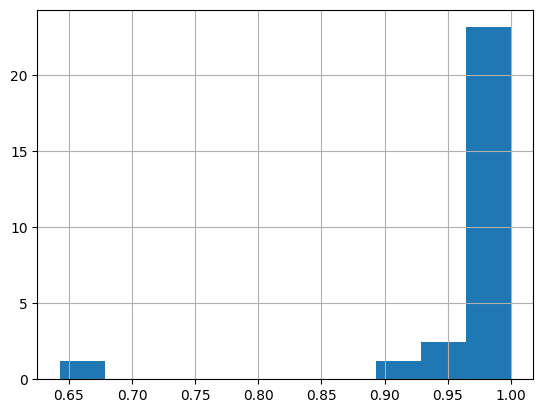

In [15]:
df.score.hist(density = True)

In [18]:
# Filter dataframe for scores not equal to 1 and sort by score in descending order
filtered_df = df[df['score'] != 1].sort_values(by='score', ascending=False)

# Reorder columns: ocr_text, corrected_ocr, score, length
columns_ordered = ['ocr_text', 'OCR_CORRECTION', 'score', 'length']
filtered_df_ordered = filtered_df[columns_ordered]

# Display all values
print("Filtered dataframe with scores != 1 (sorted by score descending):")
print("Columns: ocr_text | OCR_CORRECTION | score | length")
print(filtered_df_ordered)

# Save to CSV file with reordered columns
output_file = "/Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/chemistry/filtered_results_chem.csv"

filtered_df_ordered.to_csv(output_file, index=False)

print(f"\nResults saved to: {output_file}")
print(f"Number of rows with score != 1: {len(filtered_df_ordered)}")
print("CSV columns order: ocr_text, OCR_CORRECTION, score, length")


Filtered dataframe with scores != 1 (sorted by score descending):
Columns: ocr_text | OCR_CORRECTION | score | length
                                             ocr_text  \
13                   8. (4) a is false, but r is true   
8   amphoteric oxides are the oxides which can be ...   
2                             2. (1) caco₃ -> ca(oh)₂   
3   naoh + nh₄so₄ → so₂ a) ignites which with pup ...   

                                       OCR_CORRECTION     score  length  
13                   8. (d) a is false, but r is true  0.958333      32  
8   Q5 Amphoteric oxides are the oxides which can ...  0.941176     190  
2                              2. (1) caco₃ , ca(oh)₂  0.894737      22  
3                2. (a) ignites which with pup sound.  0.642857      36  

Results saved to: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/chemistry/filtered_results_chem.csv
Number of rows with score != 1: 4
CSV columns order

In [ ]:
df.sort_values(by='score',ascending=False)

,ocr_text,OCR_CORRECTION,score,length
0,1. 3,1. 3,1.000000,4
1,1) (1) 3,1) (1) 3,1.000000,8
124,13. -> (1) similar,13. -> (1) similar,1.000000,18
125,13. 1) similar,13. 1) similar,1.000000,14
126,q13- similar,q13- similar,1.000000,12
...,...,...,...,...
190,"22. a(1,2); b(2,3); c(6,5); d(x,y).<diagram_4>...","22. A(1,2); B(2,3); C(6,5); D(x,y)\nAB = DC\nA...",0.424242,424
101,"11) tanθ = 1/2sinθ = 1/√5, cosθ = 2/√5sinθ = 1...",11 ) tanθ = 1/2.\nTo prove 1/2 sinθ.cosθ = 1/5...,0.377953,81
144,16. givenδabe ~ δacd.<diagram_3>to prove thatδ...,6: Given\nΔABE ≅ ΔACD.\nTo Prove that\nΔADE ~ ...,0.345205,167
63,"ans 7.let the zeroes be α,β,γ.αβγ = -c/1so, (-...","Ans 7. We know, αβγ = d/a\nSo, (-1)βγ = c/1\nβ...",0.294798,248


=== OPTION 1: Download main DataFrame ===
Main DataFrame saved to: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/chemistry/maths_numerical.csv
Shape: (190, 4)
Columns: ['Ground_Truth', 'Gemini_ocr', 'score', 'length']

=== OPTION 2: Filtered DataFrame (already saved) ===
Filtered DataFrame already saved to: /Users/simrannaik/Desktop/solution_improvement/ds-prototypes/subjective_grading/solution_improvement/z2_ocr_gemini_pcmb/chemistry/filtered_results_chem.csv


NameError: name 'filtered_df_ordered' is not defined